# Start SBI Dataset

This notebook prepares the new 512-row Battaglia y100/y102 dataset for `sbi`. It reads the combined cluster output NPZ, keeps the Sobol parameter rows, converts raw spectra to `log10(D_l)`, estimates the paired-lightcone scatter, and exposes `torch.float32` tensors ready for `inference.append_simulations(theta, x)`.


In [7]:
from matplotlib.ticker import LinearLocator, MaxNLocator
import matplotlib.pyplot as plt
from pathlib import Path
import sys

import numpy as np

try:
    import torch
except ModuleNotFoundError:
    torch = None

try:
    import pandas as pd
except ModuleNotFoundError:
    pd = None

try:
    from sbi.analysis import pairplot
    from sbi.analysis.plotting_classes import KdeOffDiagOptions
    from sbi.analysis.plotting_classes import (
        HistDiagOptions,
        HistOffDiagOptions,
        FigOptions,
        ScatterOffDiagOptions,
        ContourOffDiagOptions,
    )
    from sbi.inference import NPE
except ModuleNotFoundError:
    pairplot = None
    KdeOffDiagOptions = None
    HistDiagOptions = None
    HistOffDiagOptions = None
    FigOptions = None
    NPE = None


In [34]:
# Make the notebook work whether Jupyter is started from the repo root, SBI_analysis, emulator_tSZ, or tSZ_visuals.
import json

CWD = Path.cwd().resolve()
if CWD.name == "SBI_analysis":
    PROJECT_ROOT = CWD.parent
elif (CWD / "SBI_analysis").is_dir():
    PROJECT_ROOT = CWD
elif (CWD.parent / "SBI_analysis").is_dir():
    PROJECT_ROOT = CWD.parent
else:
    PROJECT_ROOT = CWD

SBI_DIR = PROJECT_ROOT / "SBI_analysis"
if str(SBI_DIR) not in sys.path:
    sys.path.insert(0, str(SBI_DIR))

from sbi_utils import cl_to_log10_dl, estimate_lightcone_sigma, prior_bounds, selected_ell_mask

# Planck-only setup: existing 100k emulator dataset already binned into the 16 Planck bandpowers.
EMULATOR_SBI_DATA_PATH = (
    PROJECT_ROOT
    / "emulator_tSZ"
    / "outputs"
    / "binned_16e3_16"
    / "sbi16e3_bin16_dataset_100_000.npz"
)

emulator_sbi_candidates = sorted(
    (PROJECT_ROOT / "emulator_tSZ" / "outputs" / "binned_16e3_16").glob("sbi16e3_bin16_dataset_*.npz")
)
DATA_PATH = emulator_sbi_candidates[-1] if emulator_sbi_candidates else EMULATOR_SBI_DATA_PATH

METADATA_PATH = DATA_PATH.with_name(DATA_PATH.stem + "_metadata.csv")
MANIFEST_PATH = DATA_PATH.with_name(DATA_PATH.stem + "_manifest.json")

# Synthetic Battaglia12 observation. This is binned below with the same Planck bin ranges as DATA_PATH.
OBS_Y100_PATH = PROJECT_ROOT / "HPC_output" / "HalfDome" / "tSZ_HalfDome_fiducial_nside4096_cluster.npy"
OBS_Y102_PATH = PROJECT_ROOT / "HPC_output" / "HalfDome" / "tSZ_HalfDome102_fiducial_nside4096_cluster.npy"

# No-noise Planck-binning run: do not add SO/Planck noise and do not apply an extra Gaussian beam.
GAUSSIAN_BEAM_FWHM_ARCMIN = 10.0
USE_GAUSSIAN_BEAM_FOR_SBI = True

ELL_MIN = 21
ELL_MAX = 1411
DEVICE = "cuda" if torch is not None and torch.cuda.is_available() else "cpu"

# Same 9-parameter Sobol prior used to generate the emulator-SBI dataset.
SOBOL_PRIOR_BOUNDS = {
    "P0": [1.832524, 34.341221],
    "xc": [0.150011, 0.844503],
    "beta": [3.480627, 5.216611],
    "alpha_m_P0": [0.000312, 0.292251],
    "alpha_m_xc": [-0.099718, 0.099795],
    "alpha_m_beta": [-0.019935, 0.099767],
    "alpha_z_P0": [-1.363457, -0.228839],
    "alpha_z_xc": [0.147393, 1.314474],
    "alpha_z_beta": [0.083808, 0.745884],
}

print(f"DATA_PATH: {DATA_PATH}")
print(f"exists:    {DATA_PATH.exists()}")
DATA_PATH


DATA_PATH: \\wsl.localhost\myrootfs\home\cbllover\HalfDome\emulator_tSZ\outputs\binned_16e3_16\sbi16e3_bin16_dataset_100_000.npz
exists:    True


WindowsPath('//wsl.localhost/myrootfs/home/cbllover/HalfDome/emulator_tSZ/outputs/binned_16e3_16/sbi16e3_bin16_dataset_100_000.npz')

In [35]:
from sbi.analysis.plotting_classes import (
    FigOptions,
    HistDiagOptions,
    KdeDiagOptions,
    ScatterDiagOptions,
    ScatterOffDiagOptions,
    ContourOffDiagOptions,
    KdeOffDiagOptions,
    HistOffDiagOptions,
)


def _as_tensor(x):
    if x is None:
        return None
    if hasattr(x, "detach"):
        return x.detach().cpu()
    return torch.as_tensor(x)


def _is_none_kind(kind):
    return kind is None or str(kind).lower() in ["none", "off", "empty", "blank"]


def _diag_options(kind, color, cmap, bins):
    kind = str(kind).lower()

    if kind == "hist":
        return HistDiagOptions(
            mpl_kwargs={
                "color": color,
                "bins": bins,
                "alpha": 0.45,
                "histtype": "stepfilled",
                "density": True,
            }
        )

    elif kind == "kde":
        return KdeDiagOptions(
            mpl_kwargs={
                "color": color,
                "alpha": 0.9,
            }
        )

    elif kind == "scatter":
        return ScatterDiagOptions(
            mpl_kwargs={
                "color": color,
                "s": 8,
                "alpha": 0.3,
            }
        )

    else:
        raise ValueError(
            f"Unsupported diagonal plot kind: {kind}. "
            "Use 'hist', 'kde', or 'scatter'."
        )


def _offdiag_options(
    kind,
    color,
    cmap,
    hidden=False,
    scatter_cmap=None,
    scatter_gradient=False,
    n_points=None,
):
    kind = str(kind).lower()

    if hidden:
        return ScatterOffDiagOptions(
            mpl_kwargs={
                "color": color,
                "s": 0,
                "alpha": 0.0,
            }
        )

    if kind == "scatter":
        if scatter_gradient:
            if n_points is None:
                raise ValueError("n_points is required for scatter_gradient=True.")

            scatter_kwargs = {
                "color": None,
                "c": np.linspace(0, 1, n_points),
                "cmap": scatter_cmap if scatter_cmap is not None else cmap,
                "s": 6,
                "alpha": 0.35,
                "rasterized": True,
            }
        else:
            scatter_kwargs = {
                "color": color,
                "s": 6,
                "alpha": 0.20,
                "rasterized": True,
            }

        return ScatterOffDiagOptions(mpl_kwargs=scatter_kwargs)

    elif kind == "contour":
        return ContourOffDiagOptions(
            mpl_kwargs={
                "colors": color,
                "alpha": 0.9,
            },
            levels=[0.68, 0.95],
        )

    elif kind == "kde":
        return KdeOffDiagOptions(
            mpl_kwargs={
                "cmap": cmap,
                "alpha": 0.8,
            }
        )

    elif kind == "hist":
        return HistOffDiagOptions(
            mpl_kwargs={
                "cmap": cmap,
            }
        )

    else:
        raise ValueError(
            f"Unsupported off-diagonal plot kind: {kind}. "
            "Use 'scatter', 'contour', 'kde', 'hist', or 'none'."
        )

def sbi_pairplot(
    samples,
    param_names,
    true_values=None,
    sample_labels=None,
    colors=None,
    cmaps=None,
    limits=None,
    subset=None,
    diag="hist",
    upper="contour",
    lower="scatter",
    bins=40,
    figsize=None,
    title=None,
    savepath=None,
    scatter_cmap=None,
    scatter_gradient=False,
    diag_param_labels=True,
):
    """
    Flexible pairplot wrapper for sbi posterior samples.

    Parameters
    ----------
    samples:
        Tensor/array of shape (N, ndim), or list of such arrays.
    param_names:
        List of parameter names.
    true_values:
        Optional fiducial/true parameter vector with shape (ndim,).
    sample_labels:
        Optional labels for multiple posterior sample sets.
    colors:
        Optional list of colors, one per sample set.
    cmaps:
        Optional list of colormaps, one per sample set.
    limits:
        Optional axis limits passed to sbi.analysis.pairplot.
    subset:
        Optional subset of parameters to plot, e.g. [0, 2, 4].
    diag:
        'hist', 'kde', or 'scatter'.
    upper:
        'scatter', 'contour', 'kde', 'hist', or 'none'.
    lower:
        'scatter', 'contour', 'kde', 'hist', or 'none'.
    """

    from matplotlib.ticker import LinearLocator as _LinearLocator

    # Allow one dataset or multiple datasets
    if not isinstance(samples, (list, tuple)):
        samples = [samples]

    samples = [_as_tensor(s) for s in samples]
    n_sets = len(samples)

    ndim = samples[0].shape[1]

    for s in samples:
        if s.ndim != 2:
            raise ValueError("Each sample set must have shape (N, ndim).")
        if s.shape[1] != ndim:
            raise ValueError("All sample sets must have the same number of parameters.")

    if len(param_names) != ndim:
        raise ValueError(
            f"param_names has length {len(param_names)}, but samples have ndim={ndim}."
        )

    if colors is None:
        colors = [f"C{i}" for i in range(n_sets)]

    if cmaps is None:
        default_cmaps = ["Blues", "Oranges", "Greens", "Purples", "Greys"]
        cmaps = [default_cmaps[i % len(default_cmaps)] for i in range(n_sets)]

    if sample_labels is None:
        sample_labels = [f"samples {i}" for i in range(n_sets)]

    if len(colors) != n_sets:
        raise ValueError("colors must have one entry per sample set.")

    if len(cmaps) != n_sets:
        raise ValueError("cmaps must have one entry per sample set.")

    if len(sample_labels) != n_sets:
        raise ValueError("sample_labels must have one entry per sample set.")

    points = None
    point_labels = []
    if true_values is not None:
        points = _as_tensor(true_values)
        if points.ndim == 1:
            points = points[None, :]
        point_labels = [r"$\theta_\mathrm{true}$"]

    hide_upper = _is_none_kind(upper)
    hide_lower = _is_none_kind(lower)

    # sbi needs a valid plot type, so use invisible scatter internally.
    upper_for_pairplot = "scatter" if hide_upper else str(upper).lower()
    lower_for_pairplot = "scatter" if hide_lower else str(lower).lower()

    diag_kwargs = [
        _diag_options(diag, colors[i], cmaps[i], bins)
        for i in range(n_sets)
    ]

    upper_kwargs = [
        _offdiag_options(
            upper_for_pairplot,
            colors[i],
            cmaps[i],
            hidden=hide_upper,
            scatter_cmap=scatter_cmap,
            scatter_gradient=scatter_gradient and upper_for_pairplot == "scatter",
            n_points=samples[i].shape[0],
        )
        for i in range(n_sets)
    ]

    lower_kwargs = [
        _offdiag_options(
            lower_for_pairplot,
            colors[i],
            cmaps[i],
            hidden=hide_lower,
            scatter_cmap=scatter_cmap,
            scatter_gradient=scatter_gradient and lower_for_pairplot == "scatter",
            n_points=samples[i].shape[0],
        )
        for i in range(n_sets)
    ]

    if figsize is None:
        ndim_plot = len(subset) if subset is not None else ndim
        figsize = (2.4 * ndim_plot, 2.4 * ndim_plot)

    fig, axes = pairplot(
        samples,
        points=points,
        labels=param_names,
        limits=limits,
        subset=subset,
        diag=[str(diag).lower()] * n_sets,
        upper=[upper_for_pairplot] * n_sets,
        lower=[lower_for_pairplot] * n_sets,
        diag_kwargs=diag_kwargs,
        upper_kwargs=upper_kwargs,
        lower_kwargs=lower_kwargs,
        figsize=figsize,
        fig_kwargs=FigOptions(
            legend=True,
            samples_labels=sample_labels,
            samples_colors=colors,
            points_labels=point_labels,
            points_colors=["k"],
            points_offdiag={"marker": "+", "markersize": 14},
            points_diag={"marker": "+", "markersize": 14},
            title=title,
        ),
    )

    # Remove upper/lower triangle if requested
    axes_arr = np.asarray(axes)

    if axes_arr.ndim == 2:
        ndim_plot = axes_arr.shape[0]

        if hide_lower:
            for i in range(ndim_plot):
                for j in range(i):
                    axes_arr[i, j].clear()
                    axes_arr[i, j].set_axis_off()

        if hide_upper:
            for i in range(ndim_plot):
                for j in range(i + 1, ndim_plot):
                    axes_arr[i, j].clear()
                    axes_arr[i, j].set_axis_off()

    # Fix labels when one triangle is hidden.
    # sbi normally labels mostly outer axes, which may have been hidden.
    if diag_param_labels and axes_arr.ndim == 2:
        if subset is None:
            plotted_param_names = list(param_names)
        else:
            plotted_param_names = [param_names[i] for i in subset]

        for i, name in enumerate(plotted_param_names):
            ax = axes_arr[i, i]
            ax.set_xlabel(name)
            ax.set_title(name)

    if axes_arr.ndim == 2:
        for ax in axes_arr.ravel():
            if not ax.axison:
                continue
            ax.xaxis.set_major_locator(_LinearLocator(3))
            ax.yaxis.set_major_locator(_LinearLocator(3))
            ax.tick_params(
                axis="both",
                which="major",
                labelsize=8,
                bottom=True,
                left=True,
                labelbottom=True,
                labelleft=True,
            )
            ax.tick_params(axis="x", which="major", labelrotation=45)
            for label in ax.get_xticklabels():
                label.set_rotation(45)
                label.set_ha("right")

    if savepath is not None:
        fig.savefig(savepath, dpi=200, bbox_inches="tight")

    return fig, axes

These are the true parameters that will later be used in the SBI

In [36]:
true_params = [18.1, 0.497, 4.35, 0.154, -0.00865, 0.0393, -0.758,  0.731, 0.415]

Functions that will later be applied for the compton-y profiles

In [37]:
def gaussian_beam_window(ells, fwhm_arcmin=1.6):
    """
    Gaussian beam window function B_ell.
    """
    fwhm_rad = np.deg2rad(fwhm_arcmin / 60.0)
    sigma_rad = fwhm_rad / np.sqrt(8.0 * np.log(2.0))

    B_ell = np.exp(-0.5 * ells * (ells + 1.0) * sigma_rad**2)

    return B_ell


def apply_gaussian_beam_to_cl(cl, fwhm_arcmin=1.6):
    """
    Apply Gaussian beam smoothing to an auto-power spectrum.
    """
    ells = np.arange(len(cl))
    B_ell = gaussian_beam_window(ells, fwhm_arcmin=fwhm_arcmin)

    cl_beamed = B_ell**2 * cl

    return cl_beamed, B_ell

## Read The SBI Dataset

The default dataset is the emulator-generated SBI NPZ. If it contains `x_log10_dl`, `x`, or `x_binned`, the notebook uses that pre-binned `log10(D_l)` datavector directly. If you switch back to the original 4096-profile raw `C_l` dataset, the same loader falls back to converting `C_l -> log10(D_l)` and the next section can bin it.


In [38]:
def npz_scalar_to_str(data, key, default=""):
    if key not in data.files:
        return default
    value = np.asarray(data[key])
    if value.shape == ():
        return str(value.item())
    if value.size == 1:
        return str(value.reshape(-1)[0])
    return default


def npz_json_dict(data, key):
    raw = npz_scalar_to_str(data, key, default="")
    if not raw:
        return {}
    try:
        return json.loads(raw)
    except json.JSONDecodeError:
        return {}


def masked_2d_array(data, key, mask):
    values = np.asarray(data[key], dtype=float)
    if values.ndim != 2:
        raise ValueError(f"{key} must be 2D, got shape {values.shape}")
    if values.shape[1] != mask.size:
        raise ValueError(f"{key} has {values.shape[1]} ell columns, expected {mask.size}")
    return values[:, mask]


def load_generated_sbi_dataset(path, ell_min=2, ell_max=4096):
    path = Path(path).expanduser()
    if not path.is_file():
        raise FileNotFoundError(
            f"Missing SBI dataset: {path}\\n"
            "Generate it from emulator_tSZ/train_binned_tSZ_emulator.ipynb first, "
            "or uncomment the original 4096-profile DATA_PATH block above."
        )

    with np.load(path, allow_pickle=True) as data:
        if "theta" not in data.files or "ell" not in data.files:
            raise KeyError(f"{path} must contain at least theta and ell")
        if "theta_columns" in data.files:
            theta_columns = [str(value) for value in np.asarray(data["theta_columns"]).tolist()]
        elif "x_columns" in data.files:
            theta_columns = [str(value) for value in np.asarray(data["x_columns"]).tolist()]
        else:
            raise KeyError(f"{path} is missing theta_columns or x_columns")

        ell_all = np.asarray(data["ell"], dtype=float).reshape(-1)
        mask = selected_ell_mask(ell_all, ell_min, ell_max)
        target_kind = npz_scalar_to_str(data, "target_kind", default="")
        binning_config = npz_json_dict(data, "binning_json")

        direct_key = None
        for candidate in ("x_log10_dl", "x_binned"):
            if candidate in data.files:
                direct_key = candidate
                break
        if direct_key is None and "x" in data.files:
            x_candidate = np.asarray(data["x"])
            if x_candidate.ndim == 2 and x_candidate.shape[1] == ell_all.size:
                target_lower = target_kind.lower()
                if "log10" in target_lower or "binned" in target_lower:
                    direct_key = "x"

        x_combined = None
        x_lightcones = {}
        cl_mean = None
        cl_keys = []
        data_vector_label = ""
        if direct_key is not None:
            x_combined = masked_2d_array(data, direct_key, mask)
            data_vector_label = f"{direct_key} ({target_kind or 'log10(D_l)'})"
        else:
            cl_keys = sorted(key for key in data.files if key.startswith("cl_y"))
            spectra = {
                key: masked_2d_array(data, key, mask)
                for key in cl_keys
            }

            if spectra:
                shapes = {values.shape for values in spectra.values()}
                if len(shapes) != 1:
                    raise ValueError(f"Spectrum arrays have inconsistent shapes: {shapes}")
                if len(spectra) == 1:
                    cl_mean = next(iter(spectra.values()))
                else:
                    cl_mean = np.mean(np.stack(list(spectra.values()), axis=0), axis=0)
            elif "cl_stack" in data.files:
                cl_stack = np.asarray(data["cl_stack"], dtype=float)
                if cl_stack.ndim != 3:
                    raise ValueError(f"Expected cl_stack with shape (n, n_lightcones, ell), got {cl_stack.shape}")
                cl_stack = cl_stack[:, :, mask]
                if cl_stack.shape[1] == 0:
                    raise ValueError(f"{path} contains an empty cl_stack")
                cl_mean = np.mean(cl_stack, axis=1)
            elif "cl_mean" in data.files:
                cl_mean = masked_2d_array(data, "cl_mean", mask)
            else:
                raise KeyError(f"{path} has no x_log10_dl/x_binned/x or C_l arrays matching cl_y*, cl_stack, or cl_mean")
            data_vector_label = "C_l converted to log10(D_l)"

        dataset = {
            "theta": np.asarray(data["theta"], dtype=float),
            "theta_columns": theta_columns,
            "ell": ell_all[mask],
            "cl_mean": cl_mean,
            "cl_keys": cl_keys,
            "x_combined": x_combined,
            "x_lightcones": x_lightcones,
            "source_path": str(path),
            "target_kind": target_kind,
            "data_vector_label": data_vector_label,
            "binning_config": binning_config,
            "is_prebinned": bool(direct_key is not None and ("binned" in target_kind.lower() or "bin_counts" in data.files or direct_key == "x_binned")),
        }

        for key in ("bin_counts", "bin_ell_min", "bin_ell_max"):
            if key in data.files:
                values = np.asarray(data[key])
                if values.ndim == 1 and values.shape[0] == ell_all.size:
                    values = values[mask]
                dataset[key] = values

        for key in cl_keys:
            dataset[key] = masked_2d_array(data, key, mask)

    n_rows = dataset["theta"].shape[0]
    data_rows = dataset["x_combined"].shape[0] if dataset["x_combined"] is not None else dataset["cl_mean"].shape[0]
    if n_rows != data_rows:
        raise ValueError("theta rows and spectrum rows do not match")
    if n_rows == 0:
        raise ValueError("Dataset contains no parameter rows")

    if n_rows <= 50_000:
        duplicate_count = n_rows - np.unique(dataset["theta"], axis=0).shape[0]
        if duplicate_count:
            raise ValueError(f"Found {duplicate_count} duplicate parameter rows in {path}")
    else:
        print(f"Skipping exact duplicate-row check for {n_rows} rows.")

    return dataset


dataset = load_generated_sbi_dataset(DATA_PATH, ell_min=ELL_MIN, ell_max=ELL_MAX)
param_names = list(dataset["theta_columns"])
prior_low_np, prior_high_np = prior_bounds({"prior": SOBOL_PRIOR_BOUNDS}, param_names)

if dataset["x_combined"] is not None:
    transformed = {"combined": dataset["x_combined"]}
    transformed.update(dataset.get("x_lightcones", {}))
else:
    transformed = {"combined": cl_to_log10_dl(dataset["cl_mean"], dataset["ell"])}
    for key in dataset["cl_keys"]:
        transformed[key[3:]] = cl_to_log10_dl(dataset[key], dataset["ell"])

# Keep arrays contiguous and float32 before handing them to torch.
theta_np = np.ascontiguousarray(dataset["theta"], dtype=np.float32)
x_np = np.ascontiguousarray(transformed["combined"], dtype=np.float32)
lightcone_names = [name for name in transformed if name != "combined"]
if lightcone_names:
    first_lightcone = transformed[lightcone_names[0]]
    second_lightcone = transformed[lightcone_names[1]] if len(lightcone_names) > 1 else first_lightcone
    x_y100_np = np.ascontiguousarray(transformed.get("y100", first_lightcone), dtype=np.float32)
    x_y102_np = np.ascontiguousarray(transformed.get("y102", second_lightcone), dtype=np.float32)
else:
    x_y100_np = x_np
    x_y102_np = x_np
ell_np = np.ascontiguousarray(dataset["ell"], dtype=np.float32)

if len(lightcone_names) == 1:
    combined_label = lightcone_names[0]
elif lightcone_names:
    combined_label = "mean of " + ", ".join(lightcone_names)
else:
    combined_label = dataset["data_vector_label"]

sigma_log10_dl_np = estimate_lightcone_sigma(
    x_y100_np,
    x_y102_np,
    target="single_lightcone",
    sigma_floor=1.0e-4,
    scale=1.0,
).astype(np.float32)

# Preserve the current loaded vectors. If this is the original 4096-profile dataset,
# the next section can replace these active variables with binned versions.
ell_unbinned_np = np.ascontiguousarray(ell_np, dtype=np.float32)
x_unbinned_np = np.ascontiguousarray(x_np, dtype=np.float32)
x_y100_unbinned_np = np.ascontiguousarray(x_y100_np, dtype=np.float32)
x_y102_unbinned_np = np.ascontiguousarray(x_y102_np, dtype=np.float32)
sigma_log10_dl_unbinned_np = np.ascontiguousarray(sigma_log10_dl_np, dtype=np.float32)

print(f"theta_np: {theta_np.shape}  parameters: {param_names}")
print(f"x_np:     {x_np.shape}  data vector: {combined_label}")
print(f"ell_np:   {ell_np.shape}  ell range: {ell_np[0]:.0f}-{ell_np[-1]:.0f}")
print(f"sigma:    {sigma_log10_dl_np.shape}  median={np.median(sigma_log10_dl_np):.4g}")
print(f"pre-binned dataset: {dataset['is_prebinned']}")


Skipping exact duplicate-row check for 100000 rows.
theta_np: (100000, 9)  parameters: ['P0', 'xc', 'beta', 'alpha_m_P0', 'alpha_m_xc', 'alpha_m_beta', 'alpha_z_P0', 'alpha_z_xc', 'alpha_z_beta']
x_np:     (100000, 16)  data vector: x_log10_dl (binned_log10_D_ell)
ell_np:   (16,)  ell range: 24-1247
sigma:    (16,)  median=0.0001
pre-binned dataset: True


In [39]:
# If full C_ell dataset

C_ell_full_bool = False
if C_ell_full_bool:
    ell_unbinned_np = ell_unbinned_np[:4095]
    x_unbinned_np = x_unbinned_np[:, :4095]
    x_y100_unbinned_np = x_y100_unbinned_np[:, :4095]
    x_y102_unbinned_np = x_y102_unbinned_np[:, :4095]
    sigma_log10_dl_unbinned_np = sigma_log10_dl_unbinned_np[:4095]
    print(f"Using full C_ell dataset with ell up to {ell_unbinned_np[-1]:.0f}")

## Datavector Binning

`DATA_PATH` is already binned into the 16 Planck bandpowers, so the active path leaves the training vectors unchanged. The Planck bin ranges saved in the NPZ are still used to bin the synthetic no-noise observation consistently.


In [40]:
# DATA_PATH is already binned into Planck's 16 bandpowers.
# Keep the training datavector unchanged; the bin edges are retained for observation binning/validation.
PLANCK_16_BIN_EDGES = np.asarray(
    [21, 27, 35, 46, 60, 78, 102, 133, 173, 224, 292, 380, 494, 642, 835, 1085, 1411],
    dtype=np.float64,
)

DATAVECTOR_BINNING = {
    "enabled": False,
    "mode": "custom",
    "n_bins": 16,
    "ell_min": 21,
    "ell_max": 1411,
    "custom_edges": PLANCK_16_BIN_EDGES,
    "statistic": "mean",
    "weighting": "uniform",
}

# If you switch DATA_PATH to an unbinned full-ell dataset, set enabled=True above to apply
# the same Planck 16-bin edges in this notebook.


def _bin_weights(ell_values, weighting="uniform"):
    ell_values = np.asarray(ell_values, dtype=np.float64)
    weighting = str(weighting).lower()
    if weighting in {"uniform", "none", "flat"}:
        return np.ones_like(ell_values, dtype=np.float64)
    if weighting == "ell":
        return ell_values.astype(np.float64)
    if weighting in {"2ell_plus_1", "modes", "mode_count"}:
        return 2.0 * ell_values + 1.0
    raise ValueError("weighting must be 'uniform', 'ell', or '2ell_plus_1'")


def _make_bin_edges(ell_values, config):
    ell_values = np.asarray(ell_values, dtype=np.float64)
    ell_min = float(config.get("ell_min", np.nanmin(ell_values)))
    ell_max = float(config.get("ell_max", np.nanmax(ell_values)))
    ell_min = max(ell_min, float(np.nanmin(ell_values)))
    ell_max = min(ell_max, float(np.nanmax(ell_values)))
    if not ell_max > ell_min:
        raise ValueError(f"Need ell_max > ell_min for binning, got {ell_min} and {ell_max}")

    mode = str(config.get("mode", "log")).lower()
    if mode == "custom" or config.get("custom_edges") is not None:
        edges = np.asarray(config["custom_edges"], dtype=np.float64)
        if edges.ndim != 1 or edges.size < 2:
            raise ValueError("custom_edges must be a one-dimensional sequence with at least two values")
    else:
        n_bins = int(config.get("n_bins", 32))
        if n_bins < 1:
            raise ValueError("n_bins must be positive")
        if mode == "log":
            if ell_min <= 0:
                raise ValueError("log binning requires ell_min > 0")
            edges = np.geomspace(ell_min, ell_max, n_bins + 1)
        elif mode == "linear":
            edges = np.linspace(ell_min, ell_max, n_bins + 1)
        else:
            raise ValueError("mode must be 'log', 'linear', or 'custom'")

    edges = np.asarray(edges, dtype=np.float64)
    edges = np.unique(edges)
    if edges.size < 2:
        raise ValueError("Binning edges collapsed to fewer than two unique values")
    if np.any(np.diff(edges) <= 0):
        raise ValueError("Binning edges must be strictly increasing")
    return edges


def _split_members_to_target(members, ell_values, target_n_bins):
    members = list(members)
    target_n_bins = int(target_n_bins)
    if target_n_bins <= len(members):
        return members

    log_ell = np.log(np.maximum(np.asarray(ell_values, dtype=np.float64), 1.0))
    while len(members) < target_n_bins:
        splittable = [i for i, idx in enumerate(members) if idx.size > 1]
        if not splittable:
            break

        def bin_width(i):
            idx = members[i]
            return log_ell[idx[-1]] - log_ell[idx[0]]

        widest = max(splittable, key=bin_width)
        idx = members[widest]
        midpoint = 0.5 * (log_ell[idx[0]] + log_ell[idx[-1]])
        split_at = int(np.searchsorted(log_ell[idx], midpoint, side="right"))
        split_at = min(max(split_at, 1), idx.size - 1)
        members[widest : widest + 1] = [idx[:split_at], idx[split_at:]]

    return members


def _summarize_bin_members(members, ell_values, weighting, centers=None):
    counts = []
    bin_min = []
    bin_max = []
    computed_centers = []
    for idx in members:
        weights = _bin_weights(ell_values[idx], weighting)
        computed_centers.append(np.average(ell_values[idx], weights=weights))
        counts.append(idx.size)
        bin_min.append(ell_values[idx[0]])
        bin_max.append(ell_values[idx[-1]])
    if centers is None:
        centers = computed_centers
    return {
        "centers": np.asarray(centers, dtype=np.float32),
        "counts": np.asarray(counts, dtype=np.int64),
        "bin_min": np.asarray(bin_min, dtype=np.float32),
        "bin_max": np.asarray(bin_max, dtype=np.float32),
    }


def make_ell_binning(ell_values, config):
    ell_values = np.asarray(ell_values, dtype=np.float64)
    weighting = config.get("weighting", "uniform")
    if not bool(config.get("enabled", True)):
        members = [np.array([i], dtype=np.int64) for i in range(ell_values.size)]
        summary = _summarize_bin_members(members, ell_values, weighting)
        return {
            "enabled": False,
            "edges": None,
            "members": members,
            **summary,
        }

    edges = _make_bin_edges(ell_values, config)
    selected = (ell_values >= edges[0]) & (ell_values <= edges[-1])
    bin_index = np.digitize(ell_values, edges, right=False) - 1
    bin_index[ell_values == edges[-1]] = edges.size - 2

    members = []
    for i in range(edges.size - 1):
        idx = np.flatnonzero(selected & (bin_index == i))
        if idx.size:
            members.append(idx.astype(np.int64))

    if not members:
        raise ValueError("Binning produced no non-empty bins")

    mode = str(config.get("mode", "log")).lower()
    if mode != "custom" and config.get("custom_edges") is None:
        members = _split_members_to_target(members, ell_values, int(config.get("n_bins", len(members))))

    summary = _summarize_bin_members(members, ell_values, weighting)
    return {
        "enabled": True,
        "edges": edges.astype(np.float32),
        "members": members,
        **summary,
    }


def make_binning_from_bin_ranges(bin_min, bin_max, centers, weighting="uniform"):
    bin_min = np.asarray(bin_min, dtype=np.float64).reshape(-1)
    bin_max = np.asarray(bin_max, dtype=np.float64).reshape(-1)
    centers = np.asarray(centers, dtype=np.float64).reshape(-1)
    if not (bin_min.size == bin_max.size == centers.size):
        raise ValueError("bin_min, bin_max, and centers must have the same length")

    source_ell = np.arange(int(np.floor(bin_min.min())), int(np.ceil(bin_max.max())) + 1, dtype=np.float64)
    members = []
    for lo, hi, center in zip(bin_min, bin_max, centers):
        idx = np.flatnonzero((source_ell >= lo) & (source_ell <= hi))
        if idx.size == 0:
            idx = np.array([int(np.argmin(np.abs(source_ell - center)))], dtype=np.int64)
        members.append(idx.astype(np.int64))
    summary = _summarize_bin_members(members, source_ell, weighting, centers=centers)
    return source_ell.astype(np.float32), {
        "enabled": True,
        "edges": None,
        "members": members,
        **summary,
    }


def bin_last_axis(values, binning, ell_values, statistic="mean", weighting="uniform"):
    values = np.asarray(values)
    ell_values = np.asarray(ell_values, dtype=np.float64)
    if values.shape[-1] != ell_values.size:
        raise ValueError(f"Last axis has length {values.shape[-1]}, expected {ell_values.size}")

    statistic = str(statistic).lower()
    pieces = []
    for idx in binning["members"]:
        selected = values[..., idx]
        if statistic == "mean":
            weights = _bin_weights(ell_values[idx], weighting)
            pieces.append(np.average(selected, axis=-1, weights=weights))
        elif statistic == "median":
            pieces.append(np.median(selected, axis=-1))
        else:
            raise ValueError("statistic must be 'mean' or 'median'")
    return np.stack(pieces, axis=-1)


if dataset.get("is_prebinned") and DATAVECTOR_BINNING["enabled"]:
    print("Warning: DATA_PATH already appears binned; DATAVECTOR_BINNING would bin it again.")

ell_binning = make_ell_binning(ell_unbinned_np, DATAVECTOR_BINNING)
if DATAVECTOR_BINNING["enabled"]:
    requested_bins = int(DATAVECTOR_BINNING.get("n_bins", len(ell_binning["members"])))
    if len(ell_binning["members"]) != requested_bins:
        raise ValueError(
            f"DATAVECTOR_BINNING requested {requested_bins} bins, but only "
            f"{len(ell_binning['members'])} non-empty bins were produced. "
            f"Input ell range is {ell_unbinned_np[0]:.0f}-{ell_unbinned_np[-1]:.0f}; "
            "for Planck binning it must include ell=21..1411."
        )
if DATAVECTOR_BINNING["enabled"]:
    x_np = np.ascontiguousarray(
        bin_last_axis(
            x_unbinned_np,
            ell_binning,
            ell_unbinned_np,
            statistic=DATAVECTOR_BINNING["statistic"],
            weighting=DATAVECTOR_BINNING["weighting"],
        ),
        dtype=np.float32,
    )
    x_y100_np = np.ascontiguousarray(
        bin_last_axis(
            x_y100_unbinned_np,
            ell_binning,
            ell_unbinned_np,
            statistic=DATAVECTOR_BINNING["statistic"],
            weighting=DATAVECTOR_BINNING["weighting"],
        ),
        dtype=np.float32,
    )
    x_y102_np = np.ascontiguousarray(
        bin_last_axis(
            x_y102_unbinned_np,
            ell_binning,
            ell_unbinned_np,
            statistic=DATAVECTOR_BINNING["statistic"],
            weighting=DATAVECTOR_BINNING["weighting"],
        ),
        dtype=np.float32,
    )
    ell_np = np.ascontiguousarray(ell_binning["centers"], dtype=np.float32)
    sigma_log10_dl_np = estimate_lightcone_sigma(
        x_y100_np,
        x_y102_np,
        target="single_lightcone",
        sigma_floor=1.0e-4,
        scale=1.0,
    ).astype(np.float32)
else:
    x_np = x_unbinned_np
    x_y100_np = x_y100_unbinned_np
    x_y102_np = x_y102_unbinned_np
    ell_np = ell_unbinned_np
    sigma_log10_dl_np = sigma_log10_dl_unbinned_np

source_binning_config = dataset.get("binning_config", {}) or {}
observed_binning_statistic = source_binning_config.get("statistic", DATAVECTOR_BINNING["statistic"])
observed_binning_weighting = source_binning_config.get("weighting", DATAVECTOR_BINNING["weighting"])

if all(key in dataset for key in ("bin_ell_min", "bin_ell_max")):
    observed_bin_source_ell_np, observed_ell_binning = make_binning_from_bin_ranges(
        dataset["bin_ell_min"],
        dataset["bin_ell_max"],
        ell_np,
        weighting=observed_binning_weighting,
    )
    observed_binning_label = "dataset bin ranges"
elif DATAVECTOR_BINNING["enabled"]:
    observed_bin_source_ell_np = ell_unbinned_np
    observed_ell_binning = ell_binning
    observed_binning_label = "notebook binning"
else:
    observed_bin_source_ell_np = ell_np
    observed_ell_binning = make_ell_binning(ell_np, {**DATAVECTOR_BINNING, "enabled": False})
    observed_binning_label = "active ell grid only"

BINNING_SUMMARY = {
    "enabled": bool(DATAVECTOR_BINNING["enabled"]),
    "dataset_prebinned": bool(dataset.get("is_prebinned", False)),
    "mode": DATAVECTOR_BINNING["mode"],
    "requested_n_bins": int(DATAVECTOR_BINNING["n_bins"]),
    "n_bins": int(ell_np.size),
    "statistic": DATAVECTOR_BINNING["statistic"],
    "weighting": DATAVECTOR_BINNING["weighting"],
    "observed_binning_statistic": observed_binning_statistic,
    "observed_binning_weighting": observed_binning_weighting,
    "observed_binning_label": observed_binning_label,
    "ell_min": float(ell_np[0]),
    "ell_max": float(ell_np[-1]),
    "bin_counts": observed_ell_binning["counts"],
    "bin_ell_min": observed_ell_binning["bin_min"],
    "bin_ell_max": observed_ell_binning["bin_max"],
}

print(
    f"active datavector: {x_np.shape[1]} bins; "
    f"dataset_prebinned={BINNING_SUMMARY['dataset_prebinned']}; notebook_binning={DATAVECTOR_BINNING['enabled']}"
)
print(f"ell centers: {ell_np[0]:.1f}-{ell_np[-1]:.1f}; observed binning: {observed_binning_label}")
print(f"observed source ell: {observed_bin_source_ell_np[0]:.0f}-{observed_bin_source_ell_np[-1]:.0f}")
print(f"sigma after binning: {sigma_log10_dl_np.shape}  median={np.median(sigma_log10_dl_np):.4g}")


active datavector: 16 bins; dataset_prebinned=True; notebook_binning=False
ell centers: 23.5-1247.0; observed binning: dataset bin ranges
observed source ell: 21-1410
sigma after binning: (16,)  median=0.0001


In [41]:
# Planck-only sanity checks for the active datavector.
if x_np.shape[1] != 16:
    raise ValueError(f"Planck setup expects 16 bins, got x shape {x_np.shape}")
if ell_np[-1] > 1500:
    raise ValueError(f"Planck setup should not use SO high-ell bins; got ell max {ell_np[-1]}")
print("Planck 16-bin datavector active:", x_np.shape, "ell range", (float(ell_np[0]), float(ell_np[-1])))


Planck 16-bin datavector active: (100000, 16) ell range (23.5, 1247.0)


In [42]:
PROJECT_ROOT

WindowsPath('//wsl.localhost/myrootfs/home/cbllover/HalfDome')

In [43]:
SIMULATION_DATAVECTOR_NOISE = {
    "enabled": False,
    "mode": "none",
    "path": "",
    "seed": 20260612,
    "floor_dl": 1.0e-40,
}


def add_planck_dl_noise_to_log10(
    log10_dl,
    noise_sigma_dl,
    rng=None,
    floor_dl=1.0e-40,
    min_fraction_of_signal=1.0e-3,
):
    log10_dl = np.asarray(log10_dl, dtype=np.float64)
    noise_sigma_dl = np.asarray(noise_sigma_dl, dtype=np.float64).reshape(1, -1)

    rng = np.random.default_rng() if rng is None else rng
    dl = np.power(10.0, log10_dl)

    if dl.shape[-1] != noise_sigma_dl.shape[-1]:
        raise ValueError(
            f"x has {dl.shape[-1]} bins, but the noise vector has {noise_sigma_dl.shape[-1]}. "
            "For the Planck setup, use a 16-bin D_l noise vector binned with the same Planck edges."
        )

    delta_dl = rng.normal(loc=0.0, scale=noise_sigma_dl, size=dl.shape)
    positive_limit = np.minimum(noise_sigma_dl, np.abs(dl))
    negative_limit = np.minimum(noise_sigma_dl, (1.0 - min_fraction_of_signal) * np.abs(dl))
    delta_dl = np.clip(delta_dl, -negative_limit, positive_limit)

    noisy_dl = dl + delta_dl
    noisy_dl = np.maximum(noisy_dl, min_fraction_of_signal * dl)
    return np.log10(np.maximum(noisy_dl, floor_dl)).astype(np.float32)


x_clean_np = np.ascontiguousarray(x_np, dtype=np.float32)
x_y100_clean_np = np.ascontiguousarray(x_y100_np, dtype=np.float32)
x_y102_clean_np = np.ascontiguousarray(x_y102_np, dtype=np.float32)

if SIMULATION_DATAVECTOR_NOISE["enabled"]:
    noise_path = Path(SIMULATION_DATAVECTOR_NOISE["path"]).expanduser()
    if not noise_path.is_file():
        raise FileNotFoundError(
            f"Missing 16-bin simulation noise vector: {noise_path}. "
            "Set SIMULATION_DATAVECTOR_NOISE['enabled']=False or provide a Planck 16-bin D_l noise file."
        )

    sim_noise_rng = np.random.default_rng(int(SIMULATION_DATAVECTOR_NOISE["seed"]))
    planck_noise_sigma_dl = np.asarray(np.load(noise_path), dtype=np.float32).reshape(-1)

    if planck_noise_sigma_dl.shape != x_clean_np.shape[1:]:
        raise ValueError(
            f"Noise vector has shape {planck_noise_sigma_dl.shape}, expected {x_clean_np.shape[1:]}. "
            "For this notebook, it must match the active Planck 16-bin datavector."
        )

    x_np = np.ascontiguousarray(
        add_planck_dl_noise_to_log10(
            x_clean_np,
            planck_noise_sigma_dl,
            rng=sim_noise_rng,
            floor_dl=SIMULATION_DATAVECTOR_NOISE["floor_dl"],
        ),
        dtype=np.float32,
    )
    x_y100_np = np.ascontiguousarray(
        add_planck_dl_noise_to_log10(
            x_y100_clean_np,
            planck_noise_sigma_dl,
            rng=sim_noise_rng,
            floor_dl=SIMULATION_DATAVECTOR_NOISE["floor_dl"],
        ),
        dtype=np.float32,
    )
    x_y102_np = np.ascontiguousarray(
        add_planck_dl_noise_to_log10(
            x_y102_clean_np,
            planck_noise_sigma_dl,
            rng=sim_noise_rng,
            floor_dl=SIMULATION_DATAVECTOR_NOISE["floor_dl"],
        ),
        dtype=np.float32,
    )
    simulation_noise_delta_np = np.ascontiguousarray(x_np - x_clean_np, dtype=np.float32)
else:
    planck_noise_sigma_dl = np.zeros(x_np.shape[-1], dtype=np.float32)
    simulation_noise_delta_np = np.zeros_like(x_np, dtype=np.float32)

BINNING_SUMMARY["simulation_noise"] = {
    "enabled": bool(SIMULATION_DATAVECTOR_NOISE["enabled"]),
    "mode": SIMULATION_DATAVECTOR_NOISE["mode"],
    "path": SIMULATION_DATAVECTOR_NOISE["path"],
    "seed": int(SIMULATION_DATAVECTOR_NOISE["seed"]),
    "floor_dl": float(SIMULATION_DATAVECTOR_NOISE["floor_dl"]),
}

print("simulation datavector noise enabled:", SIMULATION_DATAVECTOR_NOISE["enabled"])
print("training x clean/noisy shapes:", x_clean_np.shape, x_np.shape)
print("simulation noise delta log10(D_l):", f"rms={np.sqrt(np.mean(simulation_noise_delta_np**2)):.4g}", f"max_abs={np.max(np.abs(simulation_noise_delta_np)):.4g}")


simulation datavector noise enabled: False
training x clean/noisy shapes: (100000, 16) (100000, 16)
simulation noise delta log10(D_l): rms=0 max_abs=0


In [44]:
print("floor count:", np.sum(x_np <= np.log10(1.0e-40) + 1e-6))
print("x min/max:", np.nanmin(x_np), np.nanmax(x_np))

floor count: 0
x min/max: -19.389687 -8.702187


In [45]:
x_np

array([[-14.0821905, -13.926253 , -13.795425 , ..., -12.332118 ,
        -12.246917 , -12.170333 ],
       [-13.324978 , -13.178909 , -13.061614 , ..., -11.619241 ,
        -11.501599 , -11.3919735],
       [-13.527422 , -13.362808 , -13.2429905, ..., -12.04977  ,
        -11.983932 , -11.932468 ],
       ...,
       [-12.858602 , -12.709572 , -12.604184 , ..., -11.979986 ,
        -11.979216 , -11.996993 ],
       [-12.697737 , -12.571491 , -12.467223 , ..., -11.257973 ,
        -11.174362 , -11.101083 ],
       [-15.089327 , -14.929858 , -14.801245 , ..., -13.173036 ,
        -13.060379 , -12.953505 ]], dtype=float32)

## Optional Gaussian Beam

For the active Planck no-noise configuration this is disabled, so `x_gp` is just an alias of the clean Planck-binned `x`. Toggle `USE_GAUSSIAN_BEAM_FOR_SBI` in the config cell only for a separate beamed experiment.


In [46]:
def apply_gaussian_beam_to_log10_dl(log10_dl, ell, fwhm_arcmin=1.6):
    ell = np.asarray(ell, dtype=float)
    log10_dl = np.asarray(log10_dl, dtype=float)
    beam = gaussian_beam_window(ell, fwhm_arcmin=fwhm_arcmin)
    beam_log_factor = np.log10(np.maximum(beam**2, 1.0e-40))
    return log10_dl + beam_log_factor


Gaussian_beam_bool = bool(USE_GAUSSIAN_BEAM_FOR_SBI)
if Gaussian_beam_bool:
    x_np_gp = np.ascontiguousarray(
        apply_gaussian_beam_to_log10_dl(x_np, ell_np, fwhm_arcmin=GAUSSIAN_BEAM_FWHM_ARCMIN),
        dtype=np.float32,
    )
else:
    x_np_gp = np.ascontiguousarray(x_np, dtype=np.float32)

print("Gaussian beam enabled:", Gaussian_beam_bool, "FWHM arcmin:", GAUSSIAN_BEAM_FWHM_ARCMIN)


Gaussian beam enabled: True FWHM arcmin: 10.0


## Sobol Parameters

`theta_np` is the Sobol sequence parameter matrix from the NPZ. Rows align one-to-one with `x_np`, `x_y100_np`, and `x_y102_np`.

In [47]:
if pd is not None:
    sobol_parameters = pd.DataFrame(theta_np, columns=param_names)
    parameter_summary = pd.DataFrame(
        {
            "parameter": param_names,
            "prior_low": prior_low_np,
            "prior_high": prior_high_np,
            "sobol_min": theta_np.min(axis=0),
            "sobol_max": theta_np.max(axis=0),
        }
    )
    display(parameter_summary)
    display(sobol_parameters.head())
else:
    sobol_parameters = theta_np
    parameter_summary = list(
        zip(param_names, prior_low_np, prior_high_np, theta_np.min(axis=0), theta_np.max(axis=0))
    )
    print("parameter, prior_low, prior_high, sobol_min, sobol_max")
    for row in parameter_summary:
        print(row)

,parameter,prior_low,prior_high,sobol_min,sobol_max
0,P0,1.832524,34.341221,1.833129,34.341152
1,xc,0.150011,0.844503,0.150011,0.844492
2,beta,3.480627,5.216611,3.480649,5.216601
3,alpha_m_P0,0.000312,0.292251,0.000329,0.292250
4,alpha_m_xc,-0.099718,0.099795,-0.099718,0.099795
5,alpha_m_beta,-0.019935,0.099767,-0.019934,0.099766
6,alpha_z_P0,-1.363457,-0.228839,-1.363449,-0.228839
7,alpha_z_xc,0.147393,1.314474,0.147394,1.314433
8,alpha_z_beta,0.083808,0.745884,0.083809,0.745864


,P0,xc,beta,alpha_m_P0,alpha_m_xc,alpha_m_beta,alpha_z_P0,alpha_z_xc,alpha_z_beta
0,21.223274,0.489067,4.941288,0.209391,0.037020,0.083514,-0.495222,0.302011,0.106957
1,28.669605,0.437961,3.795599,0.078453,-0.020997,0.078794,-0.881821,1.242104,0.464094
2,27.441706,0.319979,3.828299,0.102806,0.027676,-0.004829,-1.184153,0.862526,0.221531
3,29.004410,0.526540,3.799677,0.010861,0.034141,0.072426,-0.805038,0.334879,0.603306
4,5.454699,0.151979,4.058877,0.039520,-0.035858,0.071846,-1.280807,0.289332,0.666051


## Torch Tensors For `sbi`

Use `theta` and `x` directly with `sbi`. The separate y100/y102 tensors and `sigma_log10_dl` are kept in case you want to add your own noise model or condition on one lightcone.

In [48]:
if torch is None:
    theta = theta_np
    x = x_np
    x_clean = x_clean_np
    x_simulation_noise_delta = simulation_noise_delta_np
    x_gp = x_np_gp
    x_y100 = x_y100_np
    x_y102 = x_y102_np
    ell = ell_np
    sigma_log10_dl = sigma_log10_dl_np
    prior_low = prior_low_np.astype(np.float32, copy=False)
    prior_high = prior_high_np.astype(np.float32, copy=False)
    print("Torch is not installed in this kernel; using NumPy arrays for now.")
else:
    # torch.from_numpy is zero-copy on CPU; .to(...) moves only when DEVICE is cuda.
    theta_cpu = torch.from_numpy(theta_np)
    x_cpu = torch.from_numpy(x_np)
    x_clean_cpu = torch.from_numpy(x_clean_np)
    x_simulation_noise_delta_cpu = torch.from_numpy(simulation_noise_delta_np)
    x_cpu_gp = torch.from_numpy(x_np_gp)
    x_y100_cpu = torch.from_numpy(x_y100_np)
    x_y102_cpu = torch.from_numpy(x_y102_np)
    ell_cpu = torch.from_numpy(ell_np)
    sigma_log10_dl_cpu = torch.from_numpy(sigma_log10_dl_np)
    prior_low_cpu = torch.from_numpy(prior_low_np.astype(np.float32, copy=False))
    prior_high_cpu = torch.from_numpy(prior_high_np.astype(np.float32, copy=False))

    theta = theta_cpu.to(DEVICE, non_blocking=True)
    x = x_cpu.to(DEVICE, non_blocking=True)
    x_clean = x_clean_cpu.to(DEVICE, non_blocking=True)
    x_simulation_noise_delta = x_simulation_noise_delta_cpu.to(DEVICE, non_blocking=True)
    x_gp = x_cpu_gp.to(DEVICE, non_blocking=True)
    x_y100 = x_y100_cpu.to(DEVICE, non_blocking=True)
    x_y102 = x_y102_cpu.to(DEVICE, non_blocking=True)
    ell = ell_cpu.to(DEVICE, non_blocking=True)
    sigma_log10_dl = sigma_log10_dl_cpu.to(DEVICE, non_blocking=True)
    prior_low = prior_low_cpu.to(DEVICE, non_blocking=True)
    prior_high = prior_high_cpu.to(DEVICE, non_blocking=True)

    print(theta.dtype, theta.device, theta.shape)
    print(x.dtype, x.device, x.shape)


torch.float32 cpu torch.Size([100000, 9])
torch.float32 cpu torch.Size([100000, 16])


In [49]:
# Optional: instantiate the matching sbi prior if torch and sbi are installed in this kernel.
if torch is None:
    prior = None
else:
    try:
        from sbi.utils import BoxUniform

        try:
            prior = BoxUniform(low=prior_low, high=prior_high, device=DEVICE)
        except TypeError:
            prior = BoxUniform(low=prior_low, high=prior_high)
    except ModuleNotFoundError:
        prior = None
        print("sbi is not installed in this kernel; install it before constructing BoxUniform/SNPE.")

# Your SBI code can start from here, for example:
# from sbi.inference import SNPE
# inference = SNPE(prior=prior, device=DEVICE)
# density_estimator = inference.append_simulations(theta, x).train()

prepared = {
    "theta": theta,
    "x": x,
    "x_clean": x_clean,
    "x_simulation_noise_delta": x_simulation_noise_delta,
    "x_gp": x_gp,
    "x_y100": x_y100,
    "x_y102": x_y102,
    "ell": ell,
    "sigma_log10_dl": sigma_log10_dl,
    "prior_low": prior_low,
    "prior_high": prior_high,
    "param_names": param_names,
    "prior": prior,
    "binning": BINNING_SUMMARY,
    "simulation_noise": SIMULATION_DATAVECTOR_NOISE,
    "ell_unbinned": ell_unbinned_np,
}

prepared.keys()


dict_keys(['theta', 'x', 'x_clean', 'x_simulation_noise_delta', 'x_gp', 'x_y100', 'x_y102', 'ell', 'sigma_log10_dl', 'prior_low', 'prior_high', 'param_names', 'prior', 'binning', 'simulation_noise', 'ell_unbinned'])

In [50]:
print(ell)


tensor([  23.5000,   30.5000,   40.0000,   52.0000,   68.0000,   89.0000,
         117.0000,  152.0000,  198.0000,  257.0000,  335.0000,  436.0000,
         567.0000,  738.0000,  959.0000, 1247.0000])


## Observed Fiducial Spectrum

The observed fiducial spectra are read on the full ell grid and converted to `log10(D_l)`. For emulator-generated binned datasets, the notebook reconstructs the same observed bins from the saved `bin_ell_min`/`bin_ell_max` metadata instead of re-binning the already-binned emulator dataset.


In [51]:
print("observed source ell:", observed_bin_source_ell_np.shape, observed_bin_source_ell_np[0], observed_bin_source_ell_np[-1])
print("active ell bins:", ell_np.shape, ell_np[0], ell_np[-1])


observed source ell: (1390,) 21.0 1410.0
active ell bins: (16,) 23.5 1247.0


In [52]:
SYNTHETIC_OBS_DL_PATH = PROJECT_ROOT / "HPC_output" / "HalfDome" / "tSZ_HalfDome_fiducial_nside4096_cluster.npy"
PLANCK_DL_PATH = PROJECT_ROOT / "other_sims" / "Planck" / "Dl_planck_ymap_nilc.npy"
PLANCK_NOISE_PATH = PROJECT_ROOT / "other_sims" / "Planck" / "Dl_noise_16bin_planck_ell_21_to_1411.npy"
OBSERVED_DATAVECTOR_NOISE = {
    "enabled": False,
    "mode": "none",
    "path": "",
    "seed": 1,
    "floor_dl": 1.0e-40,
}


def load_synthetic_dl_matching_source_ell(path, source_ell):
    values = np.asarray(np.load(Path(path).expanduser()), dtype=np.float64).reshape(-1)
    source_ell = np.asarray(source_ell, dtype=np.float64).reshape(-1)

    if values.size == source_ell.size:
        source_dl = values
    else:
        if not np.allclose(source_ell, np.rint(source_ell)):
            raise ValueError("source_ell must be integer-valued to index a full observed spectrum")

        ell_index = np.rint(source_ell).astype(np.int64)
        if ell_index.min() < 0 or ell_index.max() >= values.size:
            raise ValueError(
                f"{path} has length {values.size}, cannot index "
                f"ell={ell_index.min()}-{ell_index.max()}. "
                "For Planck binning the observed D_l array must cover ell=21..1411."
            )
        source_dl = values[ell_index]

    return source_ell.astype(np.float32), np.ascontiguousarray(source_dl, dtype=np.float32)


In [53]:
def load_observed_spectrum_matching_bins(path, ell_active, source_ell, source_binning):
    path = Path(path).expanduser()
    if not path.is_file():
        raise FileNotFoundError(f"Missing observed spectrum: {path}")

    values = np.asarray(np.load(path), dtype=np.float64).reshape(-1)
    ell_active = np.asarray(ell_active, dtype=np.float64).reshape(-1)
    source_ell = np.asarray(source_ell, dtype=np.float64).reshape(-1)

    if values.size == ell_active.size:
        x_dl = np.ascontiguousarray(values, dtype=np.float32)
        x_log10 = np.ascontiguousarray(np.log10(np.maximum(x_dl, 1.0e-40)), dtype=np.float32)
        return x_dl, x_log10, None

    if values.size == source_ell.size:
        source_dl = np.ascontiguousarray(values, dtype=np.float32)
    else:
        if not np.allclose(source_ell, np.rint(source_ell)):
            raise ValueError("source_ell must be integer-valued to index a full observed spectrum")

        ell_index = np.rint(source_ell).astype(np.int64)
        if ell_index.min() < 0 or ell_index.max() >= values.size:
            raise ValueError(
                f"{path} has length {values.size}, cannot index "
                f"ell={ell_index.min()}-{ell_index.max()}"
            )
        source_dl = np.ascontiguousarray(values[ell_index], dtype=np.float32)

    source_log10 = np.ascontiguousarray(np.log10(np.maximum(source_dl, 1.0e-40)), dtype=np.float32)
    x_log10 = np.ascontiguousarray(
        bin_last_axis(
            source_log10,
            source_binning,
            source_ell,
            statistic=observed_binning_statistic,
            weighting=observed_binning_weighting,
        ),
        dtype=np.float32,
    )
    x_dl = np.ascontiguousarray(np.power(10.0, x_log10), dtype=np.float32)
    return x_dl, x_log10, source_dl


def to_torch_or_numpy(values):
    values = np.ascontiguousarray(values, dtype=np.float32)
    if torch is None:
        return values
    return torch.from_numpy(values).to(DEVICE, non_blocking=True)


def load_observed_dl_noise_for_bins(path, expected_shape):
    path = Path(path).expanduser()
    if not path.is_file():
        raise FileNotFoundError(
            f"Missing observed D_l noise vector: {path}. "
            f"For the active SBI vector, provide a noise vector with shape {tuple(expected_shape)}."
        )

    noise_dl = np.asarray(np.load(path), dtype=np.float32).reshape(-1)
    expected_shape = tuple(expected_shape)
    if noise_dl.shape != expected_shape:
        raise ValueError(
            f"{path} has shape {noise_dl.shape}, expected {expected_shape}. "
            "Regenerate/rebin the observed noise with the same Planck 16-bin scheme."
        )
    return np.ascontiguousarray(noise_dl, dtype=np.float32)


synthetic_ell_np, synthetic_dl_np = load_synthetic_dl_matching_source_ell(
    SYNTHETIC_OBS_DL_PATH,
    observed_bin_source_ell_np,
)

x_observed_log10_np = np.ascontiguousarray(
    bin_last_axis(
        np.log10(np.maximum(synthetic_dl_np, 1.0e-40)),
        observed_ell_binning,
        synthetic_ell_np,
        statistic=observed_binning_statistic,
        weighting=observed_binning_weighting,
    ),
    dtype=np.float32,
)

x_observed_np = np.ascontiguousarray(10.0**x_observed_log10_np, dtype=np.float32)
x_observed_unbinned_np = synthetic_dl_np

if OBSERVED_DATAVECTOR_NOISE["enabled"]:
    observed_noise_path = OBSERVED_DATAVECTOR_NOISE["path"] or str(PLANCK_NOISE_PATH)
    observed_noise_dl_np = load_observed_dl_noise_for_bins(observed_noise_path, x_observed_np.shape)
    rng = np.random.default_rng(int(OBSERVED_DATAVECTOR_NOISE["seed"]))
    x_observed_noisy_np = np.ascontiguousarray(
        x_observed_np + rng.normal(loc=0.0, scale=observed_noise_dl_np, size=x_observed_np.shape).astype(np.float32),
        dtype=np.float32,
    )
    x_observed_noisy_log10_np = np.ascontiguousarray(
        np.log10(np.maximum(x_observed_noisy_np, 1.0e-40)),
        dtype=np.float32,
    )
else:
    observed_noise_dl_np = np.zeros_like(x_observed_np, dtype=np.float32)
    x_observed_noisy_np = np.ascontiguousarray(x_observed_np, dtype=np.float32)
    x_observed_noisy_log10_np = np.ascontiguousarray(x_observed_log10_np, dtype=np.float32)

x_observed_gp_np = np.ascontiguousarray(
    apply_gaussian_beam_to_log10_dl(
        x_observed_log10_np,
        ell_np,
        fwhm_arcmin=GAUSSIAN_BEAM_FWHM_ARCMIN,
    ) if Gaussian_beam_bool else x_observed_log10_np,
    dtype=np.float32,
)

x_observed_noisy_gp_np = np.ascontiguousarray(
    apply_gaussian_beam_to_log10_dl(
        x_observed_noisy_log10_np,
        ell_np,
        fwhm_arcmin=GAUSSIAN_BEAM_FWHM_ARCMIN,
    ) if Gaussian_beam_bool else x_observed_noisy_log10_np,
    dtype=np.float32,
)

has_y102 = OBS_Y102_PATH.is_file()
prepared.update(
    {
        "observed_noise": OBSERVED_DATAVECTOR_NOISE,
        "observed_noise_dl": to_torch_or_numpy(observed_noise_dl_np),
        "x_observed": to_torch_or_numpy(x_observed_np),
        "x_observed_log10": to_torch_or_numpy(x_observed_log10_np),
        "x_observed_gp": to_torch_or_numpy(x_observed_gp_np),
        "x_observed_noisy": to_torch_or_numpy(x_observed_noisy_np),
        "x_observed_noisy_log10": to_torch_or_numpy(x_observed_noisy_log10_np),
        "x_observed_noisy_gp": to_torch_or_numpy(x_observed_noisy_gp_np),
    }
)

print(f"observed: {x_observed_log10_np.shape}  y102={'yes' if has_y102 else 'no'}")
print(f"observed log10 vector matches training shape: {x_observed_log10_np.shape == x_np.shape[1:]}")
print("ell bins:", ell_np)
print("observed noise enabled:", OBSERVED_DATAVECTOR_NOISE["enabled"])
print("observed D_l noise:", observed_noise_dl_np.shape, f"rms={np.sqrt(np.mean(observed_noise_dl_np**2)):.4g}")


observed: (16,)  y102=yes
observed log10 vector matches training shape: True
ell bins: [  23.5   30.5   40.    52.    68.    89.   117.   152.   198.   257.
  335.   436.   567.   738.   959.  1247. ]
observed noise enabled: False
observed D_l noise: (16,) rms=0


In [54]:
### Optional real Planck y-map vector matched to the active Planck bins #####
planck_dl = np.asarray(np.load(PLANCK_DL_PATH), dtype=np.float64).reshape(-1)
if planck_dl.shape != ell_np.shape:
    raise ValueError(
        f"{PLANCK_DL_PATH.name} has shape {planck_dl.shape}, expected {ell_np.shape}. "
        "The Planck-only notebook expects the 16-bin Planck D_l vector."
    )

x_obs = to_torch_or_numpy(np.log10(np.maximum(planck_dl, 1.0e-40)).astype(np.float32))
print("x_obs real Planck:", planck_dl.shape)


x_obs real Planck: (16,)


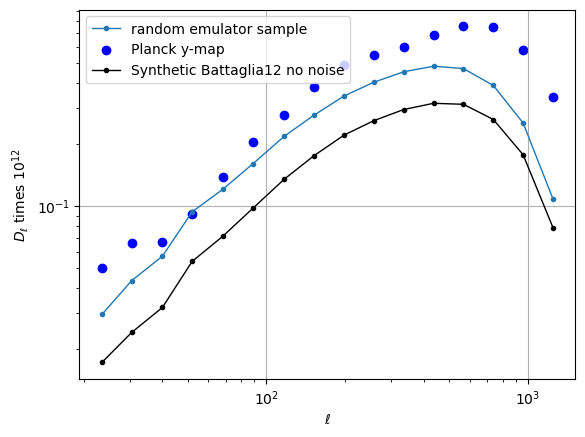

In [57]:
def as_numpy_plot(values):
    if hasattr(values, "detach"):
        return values.detach().cpu().numpy()
    return np.asarray(values)

train_plot = as_numpy_plot(prepared["x_gp"])[2]
planck_real_plot = as_numpy_plot(x_obs)
synthetic_plot = as_numpy_plot(prepared["x_observed_log10"])

plt.plot(ell_np, 10 ** (train_plot + 12), marker="o", ms=3, lw=1.0, label="random emulator sample")
plt.scatter(ell_np, 10 ** (planck_real_plot + 12), c="blue", label="Planck y-map")
plt.plot(ell_np, 10 ** (x_observed_gp_np + 12), marker="o", c="black", ms=3, lw=1.0, label="Synthetic Battaglia12 no noise")

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$D_\ell$ times $10^{12}$")
plt.grid()
plt.legend(loc="upper left")


In [58]:
CLUSTER_EXPORT_PATH = SBI_DIR / "data_for_cluster" / "planck_binned16_no_noise_sbi_run.npz"
CLUSTER_EXPORT_PATH.parent.mkdir(parents=True, exist_ok=True)

np.savez_compressed(
    CLUSTER_EXPORT_PATH,
    theta=theta_np.astype(np.float32, copy=False),
    x=x_np.astype(np.float32, copy=False),
    obs=x_observed_log10_np.astype(np.float32, copy=False),
    ell=ell_np.astype(np.float32, copy=False),
    prior_low=prior_low_np.astype(np.float32, copy=False),
    prior_high=prior_high_np.astype(np.float32, copy=False),
    param_names=np.asarray(param_names),
    bin_counts=np.asarray(BINNING_SUMMARY["bin_counts"], dtype=np.int64),
    bin_ell_min=np.asarray(BINNING_SUMMARY["bin_ell_min"], dtype=np.float32),
    bin_ell_max=np.asarray(BINNING_SUMMARY["bin_ell_max"], dtype=np.float32),
    noise_enabled=np.asarray(False),
    noise_mode=np.asarray("none"),
    source_dataset=np.asarray(str(DATA_PATH)),
    source_observed_dl=np.asarray(str(SYNTHETIC_OBS_DL_PATH)),
    binning_json=np.asarray(json.dumps(BINNING_SUMMARY, default=lambda value: np.asarray(value).tolist())),
)

summary_path = CLUSTER_EXPORT_PATH.with_suffix(".json")
summary_path.write_text(
    json.dumps(
        {
            "source_dataset": str(DATA_PATH),
            "source_observed_dl": str(SYNTHETIC_OBS_DL_PATH),
            "n_rows": int(theta_np.shape[0]),
            "x_dim": int(x_np.shape[1]),
            "theta_dim": int(theta_np.shape[1]),
            "noise_enabled": False,
            "noise_mode": "none",
            "ell_min": float(ell_np[0]),
            "ell_max": float(ell_np[-1]),
        },
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)
print("Wrote cluster Planck no-noise dataset:", CLUSTER_EXPORT_PATH)


Wrote cluster Planck no-noise dataset: \\wsl.localhost\myrootfs\home\cbllover\HalfDome\SBI_analysis\data_for_cluster\planck_binned16_no_noise_sbi_run.npz


In [59]:
prepared["x_gp"]

tensor([[-14.0826, -13.9269, -13.7965,  ..., -12.6935, -12.8570, -13.2017],
        [-13.3254, -13.1795, -13.0627,  ..., -11.9807, -12.1117, -12.4233],
        [-13.5278, -13.3634, -13.2441,  ..., -12.4112, -12.5940, -12.9638],
        ...,
        [-12.8590, -12.7102, -12.6053,  ..., -12.3414, -12.5893, -13.0283],
        [-12.6981, -12.5721, -12.4683,  ..., -11.6194, -11.7845, -12.1324],
        [-15.0897, -14.9305, -14.8023,  ..., -13.5345, -13.6705, -13.9848]])

In [60]:
np.log10(observed_noise_dl_np)+12

C:\Users\kn18001\AppData\Local\Temp\ipykernel_48772\177223620.py:1: RuntimeWarning: divide by zero encountered in log10
  np.log10(observed_noise_dl_np)+12


array([-inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
       -inf, -inf, -inf, -inf, -inf], dtype=float32)

In [61]:
# np.save("prepared_sbi_dataset_fid_bin32_noise15p.npy", obs_noisy_plot)

## Run SBI On The Planck No-Noise Dataset

The active run trains on the clean Planck-binned emulator vectors and conditions on the synthetic Battaglia12 observation with no added noise.


In [62]:
prepared["prior"]

BoxUniform(Uniform(low: torch.Size([9]), high: torch.Size([9])), 1)

In [ ]:
from sbi.inference import NLE

seed = 42
torch.manual_seed(seed)

N_TRAIN = 40_000
STOP_AFTER_EPOCHS = 35
NUM_POSTERIOR_SAMPLES = 100_000

inference = NPE(prior=prepared["prior"], density_estimator="zuko_maf")
density_estimator = inference.append_simulations(
    prepared["theta"][:N_TRAIN],
    prepared["x"][:N_TRAIN],
).train(stop_after_epochs=STOP_AFTER_EPOCHS)

x_o = prepared["x_observed_log10"]
posterior = inference.build_posterior(density_estimator)
samples = posterior.sample((NUM_POSTERIOR_SAMPLES,), x=x_o)


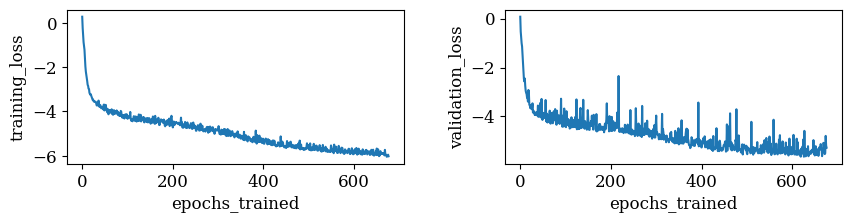

In [323]:
from sbi.analysis import plot_summary

_ = plot_summary(
    inference,
    tags=["training_loss", "validation_loss"],
    figsize=(10, 2),
)

In [80]:
samples = posterior.sample((200000,), x=x_o)


  0%|          | 0/200000 [00:00<?, ?it/s]

In [ ]:
posterior_save_path = r"outputs\posteriors\posterior_16e3emul_N4e4_binned16_s42_xo_Planck_synthetic_no_noise.npy"
np.save(posterior_save_path, samples)


In [18]:
prepared["param_names"]

['P0',
 'xc',
 'beta',
 'alpha_m_P0',
 'alpha_m_xc',
 'alpha_m_beta',
 'alpha_z_P0',
 'alpha_z_xc',
 'alpha_z_beta']

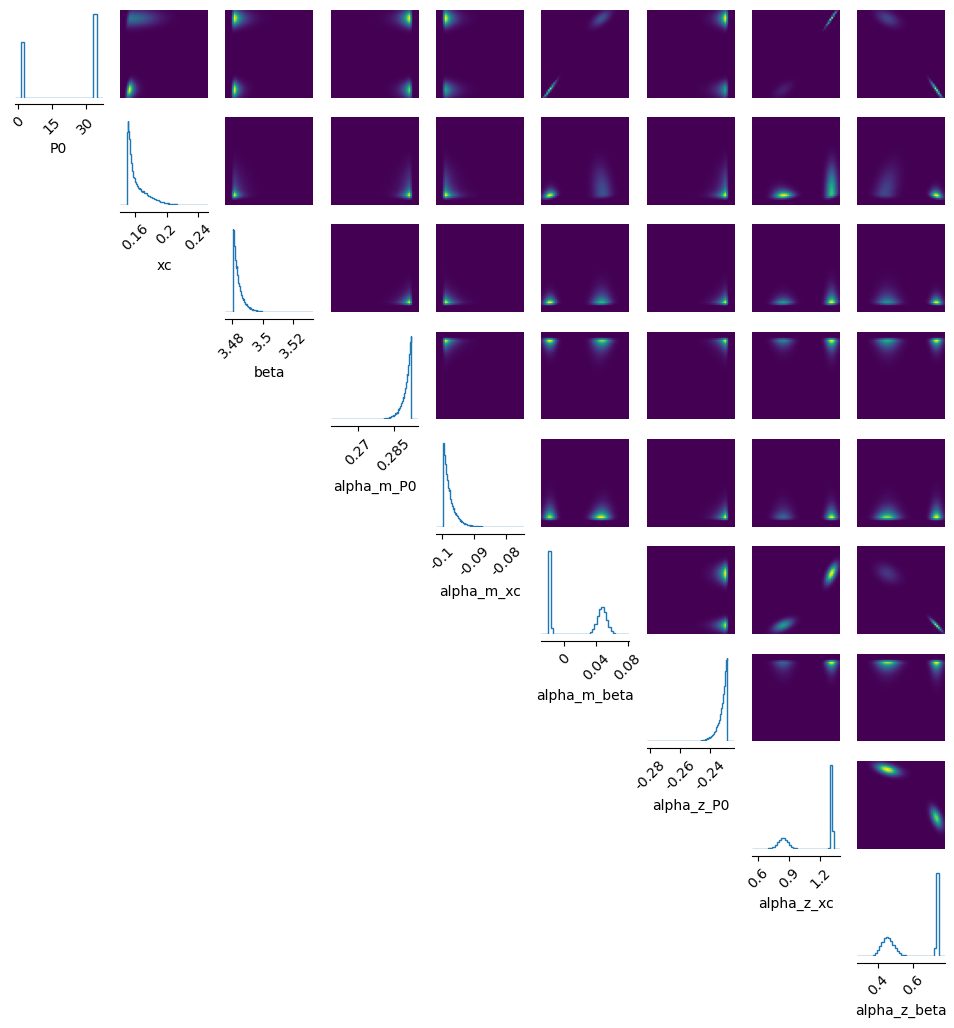

In [316]:
from matplotlib.ticker import MaxNLocator
theta_true = torch.as_tensor(np.array([true_params])).detach().cpu()


fig, axes = pairplot(
    samples,
    labels=prepared["param_names"],
    # points=theta_true,
    figsize = (12, 12),
    upper="kde",
)

axes = np.asarray(axes)
n_params = axes.shape[0]

for i in range(n_params):
    for j in range(n_params):
        ax = axes[i, j]

        # Rotate all x tick labels
        ax.tick_params(axis="x", labelrotation=45)


        # Use fewer ticks everywhere
        ax.xaxis.set_major_locator(MaxNLocator(3))
        ax.yaxis.set_major_locator(MaxNLocator(3))

# Specifically enforce 3 x-ticks on diagonal histograms
for i in range(n_params):
    ax = axes[i, i]
    ax.xaxis.set_major_locator(MaxNLocator(3))
    ax.tick_params(axis="x", labelrotation=45)

plt.savefig("pairplot_N3e4_NLE_constraints_bins9_obsSPT_noGB.png", dpi=300)
plt.show()

In [338]:
posterior_np = samples.detach().cpu().numpy()
param_names = list(prepared["param_names"])

theta_true = [18.1, 0.497, 4.35, 0.154, -0.00865,
               0.0393, -0.758,  0.731, 0.415]

true_values = np.asarray(prepared.get("theta_true", theta_true), dtype=float).reshape(-1)

summary = pd.DataFrame({
    "parameter": param_names,
    "true": true_values,
    "mean": np.mean(posterior_np, axis=0),
    "median": np.median(posterior_np, axis=0),
    "std": np.std(posterior_np, axis=0),
    "q16": np.percentile(posterior_np, 16, axis=0),
    "q84": np.percentile(posterior_np, 84, axis=0),
    "q2.5": np.percentile(posterior_np, 2.5, axis=0),
    "q97.5": np.percentile(posterior_np, 97.5, axis=0),
})
print(summary)

summary["median - true"] = summary["median"] - summary["true"]
summary["mean - true"] = summary["mean"] - summary["true"]
summary["pull"] = (summary["median"] - summary["true"]) / summary["std"]
summary["true in 68%"] = (summary["true"] >= summary["q16"]) & (summary["true"] <= summary["q84"])
summary["true in 95%"] = (summary["true"] >= summary["q2.5"]) & (summary["true"] <= summary["q97.5"])

pretty = summary.copy()
pretty["68% interval"] = pretty.apply(lambda r: f"[{r['q16']:.4g}, {r['q84']:.4g}]", axis=1)
pretty["95% interval"] = pretty.apply(lambda r: f"[{r['q2.5']:.4g}, {r['q97.5']:.4g}]", axis=1)

pretty = pretty[
    [
        "parameter",
        "true",
        "mean",
        "median",
        "std",
        "68% interval",
        "95% interval",
        "median - true",
        "pull",
        "true in 68%",
        "true in 95%",
    ]
]

display(
    pretty.style
    .format({
        "true": "{:.5g}",
        "mean": "{:.5g}",
        "median": "{:.5g}",
        "std": "{:.5g}",
        "median - true": "{:+.5g}",
        "pull": "{:+.2f}",
    })
    .background_gradient(subset=["pull"], cmap="coolwarm", vmin=-3, vmax=3)
)

      parameter      true       mean     median       std       q16  \
0            P0  18.10000  18.341475  18.135082  8.102214  9.193300   
1            xc   0.49700   0.544740   0.534271  0.132666  0.404989   
2          beta   4.35000   4.412372   4.421208  0.408200  3.970190   
3    alpha_m_P0   0.15400   0.142740   0.142163  0.069582  0.066755   
4    alpha_m_xc  -0.00865  -0.006388  -0.007557  0.046882 -0.057351   
5  alpha_m_beta   0.03930   0.043069   0.043670  0.027676  0.013141   
6    alpha_z_P0  -0.75800  -0.812370  -0.814828  0.266460 -1.102178   
7    alpha_z_xc   0.73100   0.666823   0.661482  0.247910  0.403070   
8  alpha_z_beta   0.41500   0.418341   0.421374  0.161394  0.239092   

         q84      q2.5      q97.5  
0  27.686256  4.560214  32.629253  
1   0.695348  0.318607   0.801321  
2   4.859145  3.621812   5.136400  
3   0.218631  0.015858   0.273861  
4   0.044519 -0.090001   0.084110  
5   0.072955 -0.010607   0.093099  
6  -0.524278 -1.299745  -0.307589  
7

,parameter,true,mean,median,std,68% interval,95% interval,median - true,pull,true in 68%,true in 95%
0,P0,18.1,18.341,18.135,8.1022,"[9.193, 27.69]","[4.56, 32.63]",+0.035082,+0.00,True,True
1,xc,0.497,0.54474,0.53427,0.13267,"[0.405, 0.6953]","[0.3186, 0.8013]",+0.037271,+0.28,True,True
2,beta,4.35,4.4124,4.4212,0.4082,"[3.97, 4.859]","[3.622, 5.136]",+0.071208,+0.17,True,True
3,alpha_m_P0,0.154,0.14274,0.14216,0.069582,"[0.06676, 0.2186]","[0.01586, 0.2739]",-0.011837,-0.17,True,True
4,alpha_m_xc,-0.00865,-0.0063882,-0.0075567,0.046882,"[-0.05735, 0.04452]","[-0.09, 0.08411]",+0.0010933,+0.02,True,True
5,alpha_m_beta,0.0393,0.043069,0.04367,0.027676,"[0.01314, 0.07295]","[-0.01061, 0.0931]",+0.0043695,+0.16,True,True
6,alpha_z_P0,-0.758,-0.81237,-0.81483,0.26646,"[-1.102, -0.5243]","[-1.3, -0.3076]",-0.056828,-0.21,True,True
7,alpha_z_xc,0.731,0.66682,0.66148,0.24791,"[0.4031, 0.9275]","[0.2143, 1.154]",-0.069518,-0.28,True,True
8,alpha_z_beta,0.415,0.41834,0.42137,0.16139,"[0.2391, 0.5941]","[0.1199, 0.7111]",+0.0063741,+0.04,True,True


In [351]:
#### GetDist plotting
import getdist
from getdist import MCSamples, plots

In [78]:
# -----------------------------
# True / fiducial parameters
# -----------------------------
if isinstance(theta_true, torch.Tensor):
    theta_true_np = theta_true.detach().cpu().numpy()
else:
    theta_true_np = np.asarray(theta_true)

theta_true_np = theta_true_np.reshape(-1)[:n_params]

true_markers = {
    names[i]: float(theta_true_np[i])
    for i in range(n_params)
}

In [339]:
samples_NPE_planck = np.load("outputs\posteriors\posterior_16e3train_N5e4_binned16_s42_xo_Planck_synthetic_true_noise.npy")

<>:1: SyntaxWarning: invalid escape sequence '\p'
<>:1: SyntaxWarning: invalid escape sequence '\p'
C:\Users\kn18001\AppData\Local\Temp\ipykernel_83460\1004176485.py:1: SyntaxWarning: invalid escape sequence '\p'
  samples_NPE_planck = np.load("outputs\posteriors\posterior_16e3train_N5e4_binned16_s42_xo_Planck_synthetic_true_noise.npy")


Removed no burn in
Removed no burn in


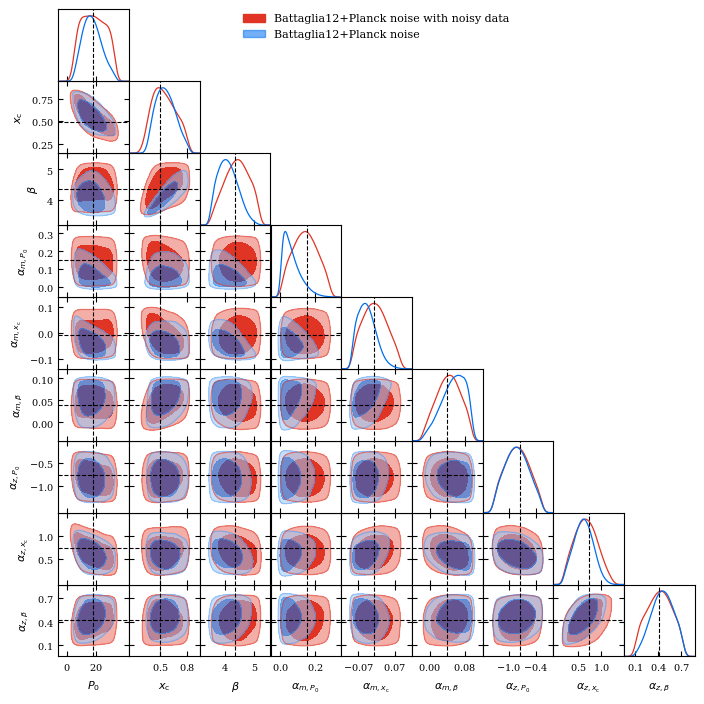

In [340]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from getdist import plots, MCSamples

# -----------------------------
# Helper: convert samples
# -----------------------------
def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

# Replace these with your two sample variables
samples_1_np = to_numpy(samples)
samples_2_np = to_numpy(samples_NPE_planck)

# Make sure both have same number of parameters
n_params = min(samples_1_np.shape[1], samples_2_np.shape[1])

samples_1_np = samples_1_np[:, :n_params]
samples_2_np = samples_2_np[:, :n_params]

# -----------------------------
# A&A-compatible labels
# -----------------------------
names = [f"p{i}" for i in range(n_params)]

labels = [
    r"P_0",
    r"x_{\rm c}",
    r"\beta",
    r"\alpha_{m,P_0}",
    r"\alpha_{m,x_{\rm c}}",
    r"\alpha_{m,\beta}",
    r"\alpha_{z,P_0}",
    r"\alpha_{z,x_{\rm c}}",
    r"\alpha_{z,\beta}",
][:n_params]

# -----------------------------
# GetDist samples
# -----------------------------
gd_samples_1 = MCSamples(
    samples=samples_1_np,
    names=names,
    labels=labels,
    label=r"Planck synthetic"
)

gd_samples_2 = MCSamples(
    samples=samples_2_np,
    names=names,
    labels=labels,
    label=r"Planck true noise"
)

for gd in [gd_samples_1, gd_samples_2]:
    gd.updateSettings({
        "smooth_scale_1D": 0.3,
        "smooth_scale_2D": 0.3,
        "fine_bins": 2048,
        "fine_bins_2D": 1024,
    })

# -----------------------------
# A&A figure style
# -----------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.bbox": "tight",
})

double_col_width_in = 18.0 / 2.54

g = plots.get_subplot_plotter(width_inch=double_col_width_in)

g.settings.axes_fontsize = 7
g.settings.lab_fontsize = 8
g.settings.legend_fontsize = 8
g.settings.alpha_filled_add = 0.55
g.settings.linewidth = 1.0
g.settings.num_plot_contours = 2
g.settings.figure_legend_frame = False
g.settings.scaling = False

# -----------------------------
# Triangle plot with two samples
# -----------------------------
g.triangle_plot(
    [gd_samples_1, gd_samples_2],
    params=names,
    filled=True,
    legend_labels=[
        r"Battaglia12+Planck noise with noisy data",
        r"Battaglia12+Planck noise",
    ],
    contour_lws=[0.9, 0.9],
    diag1d_kwargs={"linewidth": 1.0},
    markers=true_values,
    marker_args={
        "color": "black",
        "lw": 0.8,
        "ls": "--",
    },
)

plt.savefig("Planck_synthetic_generated_dataset_b16_zuko_maf_dataset_noise_comparison.png", dpi=300)
# plt.savefig("triangle_Planck_two_samples_AA.pdf", dpi=300)
plt.show()

## Dependence on dataset


In [64]:
import torch
import pandas as pd

def posterior_summary(samples, param_names=None):
    """
    samples: torch.Tensor or np.ndarray with shape (N_samples, N_params)
    """

    if not torch.is_tensor(samples):
        samples = torch.as_tensor(samples)

    samples = samples.detach().cpu()

    n_params = samples.shape[1]

    if param_names is None:
        param_names = [f"theta_{i}" for i in range(n_params)]

    mean = samples.mean(dim=0)
    median = samples.median(dim=0).values
    var = samples.var(dim=0, unbiased=True)
    std = samples.std(dim=0, unbiased=True)

    # Equal-tailed credible intervals
    ci68 = torch.quantile(samples, torch.tensor([0.16, 0.84]), dim=0)
    ci95 = torch.quantile(samples, torch.tensor([0.025, 0.975]), dim=0)

    summary = pd.DataFrame({
        "mean": mean.numpy(),
        "median": median.numpy(),
        "variance": var.numpy(),
        "std": std.numpy(),
        "68% lower": ci68[0].numpy(),
        "68% upper": ci68[1].numpy(),
        "95% lower": ci95[0].numpy(),
        "95% upper": ci95[1].numpy(),
    }, index=param_names)

    return summary


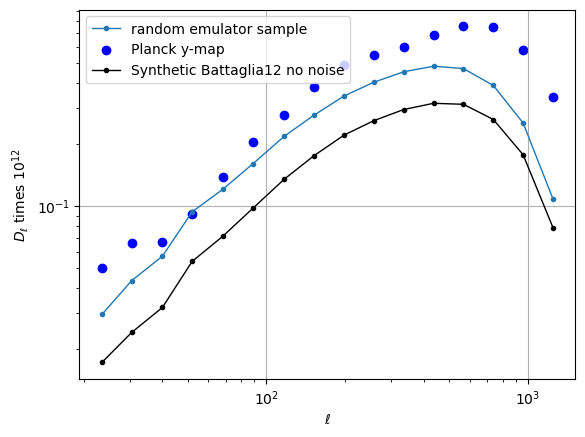

In [70]:
def as_numpy_plot(values):
    if hasattr(values, "detach"):
        return values.detach().cpu().numpy()
    return np.asarray(values)

train_plot = as_numpy_plot(prepared["x_gp"])[2]
planck_real_plot = as_numpy_plot(x_obs)
synthetic_plot = x_observed_gp_np

plt.plot(ell_np, 10 ** (train_plot + 12), marker="o", ms=3, lw=1.0, label="random emulator sample")
plt.scatter(ell_np, 10 ** (planck_real_plot + 12), c="blue", label="Planck y-map")
plt.plot(ell_np, 10 ** (synthetic_plot + 12), marker="o", c="black", ms=3, lw=1.0, label="Synthetic Battaglia12 no noise")

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$D_\ell$ times $10^{12}$")
plt.grid()
plt.legend(loc="upper left")


In [71]:
dataset_number = [1024, 2048, 4096, 8192, 16384, 32768, 50_000, 70_000, 85_000, 100_000]
DATASET_SWEEP_STOP_AFTER_EPOCHS = 35
DATASET_SWEEP_POSTERIOR_SAMPLES = 50_000
from sbi.analysis import plot_summary


x_o = x_observed_gp_np
dict_for_number = {}

for number_data in dataset_number:
    if number_data > prepared["theta"].shape[0]:
        raise ValueError(f"Requested {number_data} rows, only {prepared['theta'].shape[0]} available")

    inference = NPE(prior=prepared["prior"], density_estimator="zuko_maf")
    density_estimator_temp = inference.append_simulations(
        prepared["theta"][:number_data],
        prepared["x_gp"][:number_data],
    ).train(stop_after_epochs=DATASET_SWEEP_STOP_AFTER_EPOCHS, show_train_summary=True)

    posterior = inference.build_posterior(density_estimator_temp)
    samples = posterior.sample((DATASET_SWEEP_POSTERIOR_SAMPLES,), x=x_o)

    posterior_summary_df = posterior_summary(samples, param_names=prepared["param_names"])
    dict_for_number[number_data] = [posterior_summary_df, samples]

    # _ = plot_summary(
    #         inference,
    #         tags=["training_loss", "validation_loss"],
    #         figsize=(10, 2),
    #     )



 Neural network successfully converged after 400 epochs.
        -------------------------
        ||||| ROUND 1 STATS |||||:
        -------------------------
        Epochs trained: 400
        Best validation performance: -4.2294
        -------------------------
        


  0%|          | 0/50000 [00:00<?, ?it/s]

 Neural network successfully converged after 279 epochs.
        -------------------------
        ||||| ROUND 1 STATS |||||:
        -------------------------
        Epochs trained: 279
        Best validation performance: -5.8904
        -------------------------
        


  0%|          | 0/50000 [00:00<?, ?it/s]

 Neural network successfully converged after 463 epochs.
        -------------------------
        ||||| ROUND 1 STATS |||||:
        -------------------------
        Epochs trained: 463
        Best validation performance: -7.1382
        -------------------------
        


...

 Neural network successfully converged after 766 epochs.
        -------------------------
        ||||| ROUND 1 STATS |||||:
        -------------------------
        Epochs trained: 766
        Best validation performance: -15.5257
        -------------------------
        


  0%|          | 0/50000 [00:00<?, ?it/s]

 Neural network successfully converged after 391 epochs.
        -------------------------
        ||||| ROUND 1 STATS |||||:
        -------------------------
        Epochs trained: 391
        Best validation performance: -14.3775
        -------------------------
        


  0%|          | 0/50000 [00:00<?, ?it/s]

KeyboardInterrupt: 

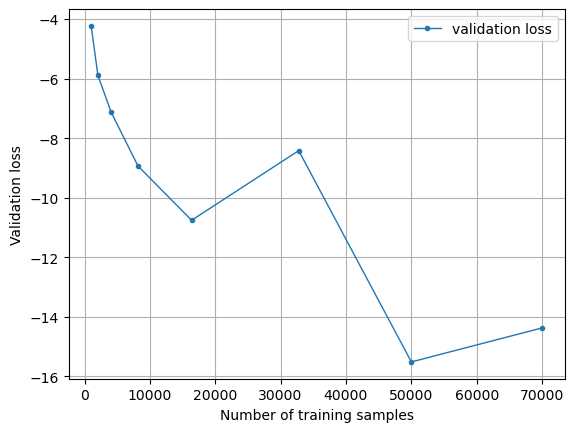

In [79]:
valid_loss = [-4.229, -5.8904, -7.138, -8.94, -10.76, -8.42, -15.52, -14.377]

plt.plot(dataset_number[:len(valid_loss)], valid_loss, marker="o", ms=3, lw=1.0, label="validation loss")
plt.xlabel("Number of training samples")
plt.ylabel("Validation loss")
plt.grid()
plt.legend()
plt.show()

In [74]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def to_numpy(x):
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def get_param_names(prepared):
    if "param_names" in prepared:
        return list(prepared["param_names"])
    if "theta_columns" in prepared:
        return list(prepared["theta_columns"])
    raise KeyError("Could not find param names in prepared.")


def get_true_theta(prepared):
    """
    Edit this if your true theta is stored under another name.
    """
    for key in ["theta_true", "true_theta", "fiducial_theta", "theta_fiducial", "theta"]:
        if key in prepared:
            return to_numpy(prepared[key]).reshape(-1)

    raise KeyError(
        "No true theta found. Add e.g. prepared['theta_true'] or define theta_true manually."
    )


def get_prior_bounds(prepared):
    """
    Tries common places for BoxUniform prior bounds.
    If this fails, define prior_low and prior_high manually.
    """
    if "prior_low" in prepared and "prior_high" in prepared:
        return to_numpy(prepared["prior_low"]), to_numpy(prepared["prior_high"])

    prior = prepared["prior"]

    if hasattr(prior, "low") and hasattr(prior, "high"):
        return to_numpy(prior.low), to_numpy(prior.high)

    if hasattr(prior, "base_dist"):
        base = prior.base_dist
        if hasattr(base, "low") and hasattr(base, "high"):
            return to_numpy(base.low), to_numpy(base.high)

    raise KeyError(
        "Could not infer prior bounds. Define prior_low and prior_high manually."
    )


# ------------------------------------------------------------
# Inputs
# ------------------------------------------------------------
param_names = get_param_names(prepared)
theta_true = np.array([18.1, 0.497, 4.35, 0.154, -0.00865, 0.0393, -0.758,  0.731, 0.415])
prior_low, prior_high = get_prior_bounds(prepared)

prior_width = prior_high - prior_low

dataset_number_sorted = sorted(dict_for_number.keys())

# ------------------------------------------------------------
# Build diagnostic table
# ------------------------------------------------------------
rows = []

for number_data in dataset_number_sorted:
    posterior_summary_df, samples = dict_for_number[number_data]

    samples_np = to_numpy(samples)

    mean = np.mean(samples_np, axis=0)
    std = np.std(samples_np, axis=0)

    std_over_prior = std / prior_width
    pull = (mean - theta_true) / std

    for j, name in enumerate(param_names):
        rows.append({
            "dataset_size": number_data,
            "parameter": name,
            "posterior_mean": mean[j],
            "posterior_std": std[j],
            "theta_true": theta_true[j],
            "prior_low": prior_low[j],
            "prior_high": prior_high[j],
            "prior_width": prior_width[j],
            "std_over_prior": std_over_prior[j],
            "pull": pull[j],
            "abs_pull": np.abs(pull[j]),
        })

sweep_diag = pd.DataFrame(rows)

display(sweep_diag)

,dataset_size,parameter,posterior_mean,posterior_std,theta_true,prior_low,prior_high,prior_width,std_over_prior,pull,abs_pull
0,1024,P0,17.879084,6.794717,18.10000,1.832524,34.341221,32.508698,0.209012,-0.032513,0.032513
1,1024,xc,0.525673,0.110978,0.49700,0.150011,0.844503,0.694492,0.159798,0.258362,0.258362
2,1024,beta,4.403417,0.389882,4.35000,3.480627,5.216611,1.735984,0.224589,0.137007,0.137007
3,1024,alpha_m_P0,0.146993,0.068802,0.15400,0.000312,0.292251,0.291939,0.235674,-0.101836,0.101836
4,1024,alpha_m_xc,-0.001921,0.046876,-0.00865,-0.099718,0.099795,0.199513,0.234951,0.143554,0.143554
...,...,...,...,...,...,...,...,...,...,...,...
67,70000,alpha_m_xc,-0.007877,0.038591,-0.00865,-0.099718,0.099795,0.199513,0.193426,0.020037,0.020037
68,70000,alpha_m_beta,0.039308,0.026553,0.03930,-0.019935,0.099767,0.119702,0.221827,0.000317,0.000317
69,70000,alpha_z_P0,-0.765768,0.262029,-0.75800,-1.363457,-0.228839,1.134618,0.230941,-0.029647,0.029647
70,70000,alpha_z_xc,0.746576,0.212664,0.73100,0.147393,1.314474,1.167081,0.182219,0.073243,0.073243


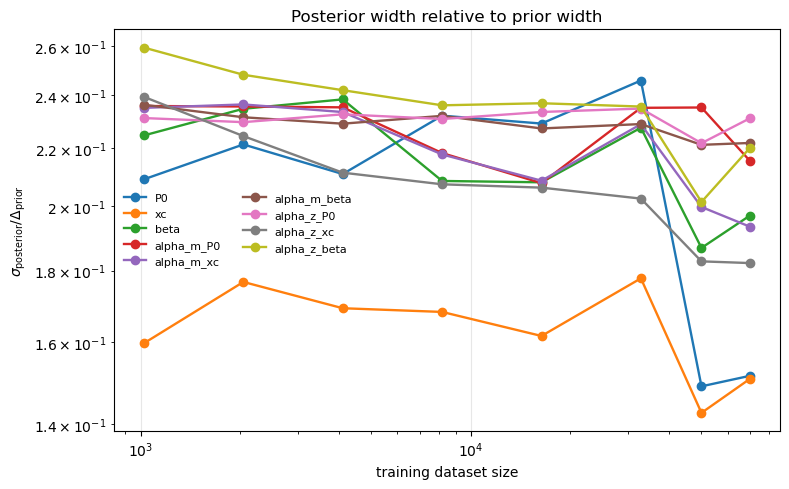

In [78]:
fig, ax = plt.subplots(figsize=(8, 5))

for name in param_names:
    d = sweep_diag[sweep_diag["parameter"] == name]
    ax.plot(
        d["dataset_size"],
        d["std_over_prior"],
        marker="o",
        lw=1.7,
        label=name,
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("training dataset size")
ax.set_ylabel(r"$\sigma_{\rm posterior} / \Delta_{\rm prior}$")
ax.set_title("Posterior width relative to prior width")
ax.grid(alpha=0.3)
ax.legend(frameon=False, fontsize=8, ncol=2)
plt.tight_layout()
# plt.xlim((1024, 16384))
plt.show()

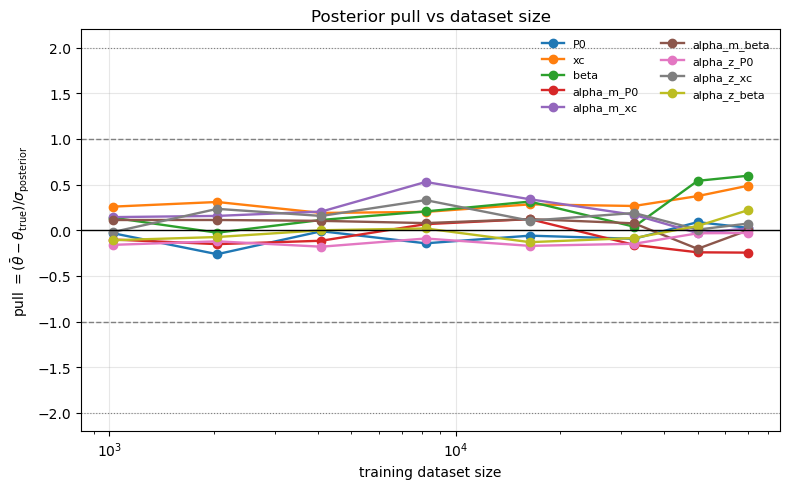

In [76]:
fig, ax = plt.subplots(figsize=(8, 5))

for name in param_names:
    d = sweep_diag[sweep_diag["parameter"] == name]
    ax.plot(
        d["dataset_size"],
        d["pull"],
        marker="o",
        lw=1.7,
        label=name,
    )

ax.axhline(0.0, color="black", lw=1.0)
ax.axhline(1.0, color="gray", lw=1.0, ls="--")
ax.axhline(-1.0, color="gray", lw=1.0, ls="--")
ax.axhline(2.0, color="gray", lw=0.8, ls=":")
ax.axhline(-2.0, color="gray", lw=0.8, ls=":")

ax.set_xscale("log")
ax.set_xlabel("training dataset size")
ax.set_ylabel(r"pull $= (\bar{\theta}-\theta_{\rm true})/\sigma_{\rm posterior}$")
ax.set_title("Posterior pull vs dataset size")
ax.grid(alpha=0.3)
ax.legend(frameon=False, fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

In [ ]:
dict_for_number[70000][1]


tensor([[22.7317,  0.4619,  4.2897,  ..., -1.0463,  0.7393,  0.3714],
        [18.3498,  0.5499,  4.5966,  ..., -0.5971,  0.5445,  0.3675],
        [16.4022,  0.6246,  4.8534,  ..., -0.7260,  0.6698,  0.4265],
        ...,
        [29.2837,  0.3281,  3.9213,  ..., -0.3819,  0.6362,  0.4180],
        [15.6284,  0.6318,  4.8800,  ..., -0.8579,  0.7890,  0.4813],
        [16.9046,  0.5517,  4.5705,  ..., -1.0770,  1.0237,  0.5932]])

Removed no burn in
Removed no burn in


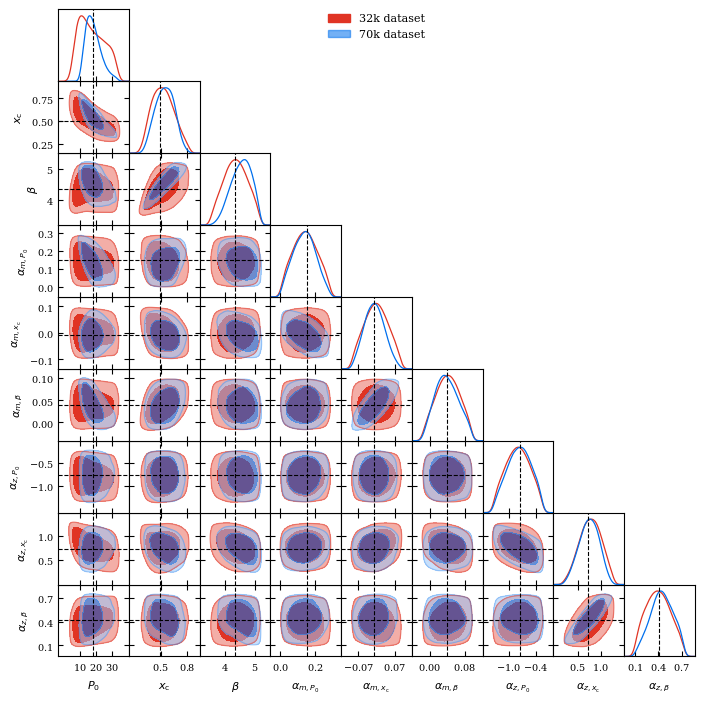

In [86]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from getdist import plots, MCSamples

# -----------------------------
# Helper: convert samples
# -----------------------------
def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

# Replace these with your two sample variables
samples_1_np = to_numpy(dict_for_number[32768][1])
samples_2_np = to_numpy(dict_for_number[70000][1])

# Make sure both have same number of parameters
n_params = min(samples_1_np.shape[1], samples_2_np.shape[1])

samples_1_np = samples_1_np[:, :n_params]
samples_2_np = samples_2_np[:, :n_params]

# -----------------------------
# A&A-compatible labels
# -----------------------------
names = [f"p{i}" for i in range(n_params)]

labels = [
    r"P_0",
    r"x_{\rm c}",
    r"\beta",
    r"\alpha_{m,P_0}",
    r"\alpha_{m,x_{\rm c}}",
    r"\alpha_{m,\beta}",
    r"\alpha_{z,P_0}",
    r"\alpha_{z,x_{\rm c}}",
    r"\alpha_{z,\beta}",
][:n_params]

# -----------------------------
# GetDist samples
# -----------------------------
gd_samples_1 = MCSamples(
    samples=samples_1_np,
    names=names,
    labels=labels,
    label=r"Planck synthetic"
)

gd_samples_2 = MCSamples(
    samples=samples_2_np,
    names=names,
    labels=labels,
    label=r"Planck true noise"
)

for gd in [gd_samples_1, gd_samples_2]:
    gd.updateSettings({
        "smooth_scale_1D": 0.3,
        "smooth_scale_2D": 0.3,
        "fine_bins": 2048,
        "fine_bins_2D": 1024,
    })

# -----------------------------
# A&A figure style
# -----------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.bbox": "tight",
})

double_col_width_in = 18.0 / 2.54

g = plots.get_subplot_plotter(width_inch=double_col_width_in)

g.settings.axes_fontsize = 7
g.settings.lab_fontsize = 8
g.settings.legend_fontsize = 8
g.settings.alpha_filled_add = 0.55
g.settings.linewidth = 1.0
g.settings.num_plot_contours = 2
g.settings.figure_legend_frame = False
g.settings.scaling = False

# -----------------------------
# Triangle plot with two samples
# -----------------------------
g.triangle_plot(
    [gd_samples_1, gd_samples_2],
    params=names,
    filled=True,
    legend_labels=[
        r"32k dataset",
        r"70k dataset",
    ],
    contour_lws=[0.9, 0.9],
    diag1d_kwargs={"linewidth": 1.0},
    markers=true_params,
    marker_args={
        "color": "black",
        "lw": 0.8,
        "ls": "--",
    },
)

plt.savefig("Planck_synthetic_generated_dataset_b16_zuko_maf_dataset_noise_comparison_dataset_gen.png", dpi=300)
# plt.savefig("triangle_Planck_two_samples_AA.pdf", dpi=300)
plt.show()

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


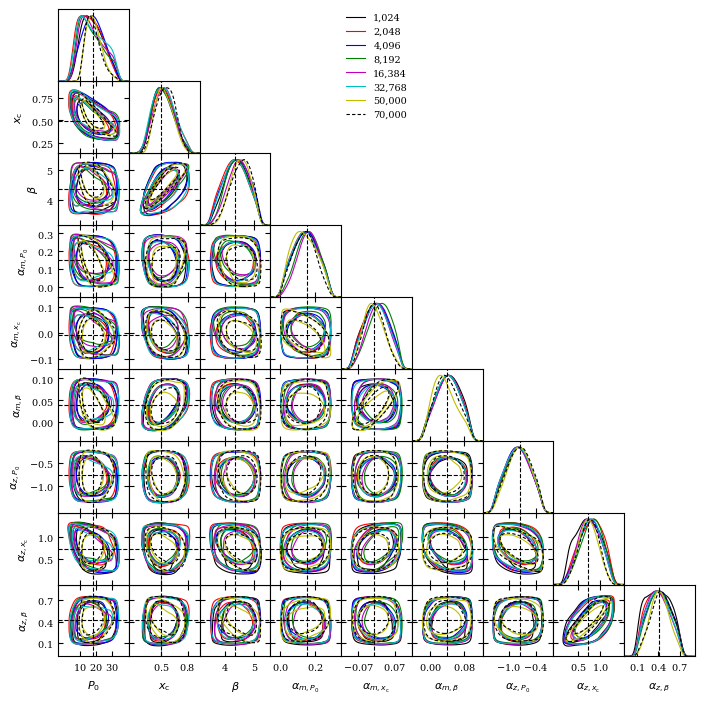

In [87]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from getdist import plots, MCSamples

# -----------------------------
# Helper: convert samples
# -----------------------------
def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

# -----------------------------
# Training-set sizes to compare
# -----------------------------
dataset_numbers = [
    1024, 2048, 4096, 8192,
    16384, 32768, 50_000, 70_000
]

# Extract posterior samples from dict_for_number
# Assumes dict_for_number[N][1] contains samples
samples_np_list = [
    to_numpy(dict_for_number[N][1])
    for N in dataset_numbers
]

# Make sure all have same number of parameters
n_params = min(s.shape[1] for s in samples_np_list)

samples_np_list = [
    s[:, :n_params]
    for s in samples_np_list
]

# -----------------------------
# A&A-compatible labels
# -----------------------------
names = [f"p{i}" for i in range(n_params)]

labels = [
    r"P_0",
    r"x_{\rm c}",
    r"\beta",
    r"\alpha_{m,P_0}",
    r"\alpha_{m,x_{\rm c}}",
    r"\alpha_{m,\beta}",
    r"\alpha_{z,P_0}",
    r"\alpha_{z,x_{\rm c}}",
    r"\alpha_{z,\beta}",
][:n_params]

# -----------------------------
# GetDist samples
# -----------------------------
gd_samples_list = []

for N, samples_np in zip(dataset_numbers, samples_np_list):
    gd = MCSamples(
        samples=samples_np,
        names=names,
        labels=labels,
        label=rf"{N:,} simulations"
    )

    gd.updateSettings({
        "smooth_scale_1D": 0.3,
        "smooth_scale_2D": 0.3,
        "fine_bins": 2048,
        "fine_bins_2D": 1024,
    })

    gd_samples_list.append(gd)

# -----------------------------
# A&A figure style
# -----------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.bbox": "tight",
})

double_col_width_in = 18.0 / 2.54

g = plots.get_subplot_plotter(width_inch=double_col_width_in)

g.settings.axes_fontsize = 7
g.settings.lab_fontsize = 8
g.settings.legend_fontsize = 7
g.settings.alpha_filled_add = 0.35
g.settings.linewidth = 0.9
g.settings.num_plot_contours = 2
g.settings.figure_legend_frame = False
g.settings.scaling = False

# -----------------------------
# Triangle plot for all training sizes
# -----------------------------
g.triangle_plot(
    gd_samples_list,
    params=names,
    filled=False,          # clearer for many datasets
    legend_labels=[
        rf"{N:,}" for N in dataset_numbers
    ],
    contour_lws=[0.8] * len(dataset_numbers),
    diag1d_kwargs={"linewidth": 0.9},
    markers=np.asarray(true_params)[:n_params],
    marker_args={
        "color": "black",
        "lw": 0.8,
        "ls": "--",
    },
)

plt.savefig(
    "Planck_dataset_size_comparison_b16_zuko_maf.png",
    dpi=300
)

# plt.savefig(
#     "Planck_dataset_size_comparison_b16_zuko_maf.pdf",
#     dpi=300
# )

plt.show()

# Generating the "observed" function

In [103]:
samples_noisy = np.load("outputs\posteriors\posterior_100_000_emulator_sample_noisy_binned32.npy")

sample_noisy_4096 = np.load("outputs\posteriors\posterior_4096_sample_noisy_binned32.npy")

<>:1: SyntaxWarning: invalid escape sequence '\p'
<>:3: SyntaxWarning: invalid escape sequence '\p'
<>:1: SyntaxWarning: invalid escape sequence '\p'
<>:3: SyntaxWarning: invalid escape sequence '\p'
C:\Users\kn18001\AppData\Local\Temp\ipykernel_30940\38969436.py:1: SyntaxWarning: invalid escape sequence '\p'
  samples_noisy = np.load("outputs\posteriors\posterior_100_000_emulator_sample_noisy_binned32.npy")
C:\Users\kn18001\AppData\Local\Temp\ipykernel_30940\38969436.py:3: SyntaxWarning: invalid escape sequence '\p'
  sample_noisy_4096 = np.load("outputs\posteriors\posterior_4096_sample_noisy_binned32.npy")


In [92]:
noisy_sample.shape

(200000, 9)

In [97]:
from matplotlib.ticker import MaxNLocator
import numpy as np
import torch
import matplotlib.pyplot as plt

theta_true = torch.as_tensor(
    np.array([true_params]),
    dtype=torch.float32
).detach().cpu()

samples_clean = samples.detach().cpu()


samples_noisy = torch.as_tensor(
    samples_noisy,
    dtype=torch.float32
).detach().cpu()
# 4096 noisy samples already available as numpy
samples_4096_noisy = torch.as_tensor(
    sample_noisy_4096,
    dtype=torch.float32
).detach().cpu()

all_samples = [
    samples_clean,
    samples_noisy,
    samples_4096_noisy,
]

sample_labels = [
    "clean 1024",
    "noisy 1024",
    "noisy 4096",
]

In [98]:
combined = np.vstack([s.numpy() for s in all_samples])

limits = []
for i in range(combined.shape[1]):
    lo, hi = np.percentile(combined[:, i], [0.5, 99.5])
    pad = 0.05 * (hi - lo)
    limits.append([lo - pad, hi + pad])

In [104]:
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
from scipy.ndimage import gaussian_filter
import numpy as np
import torch
import matplotlib.pyplot as plt

def to_numpy(x):
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def contour_levels_from_hist(H, probs=(0.68, 0.95)):
    Hflat = H.ravel()
    Hflat = Hflat[np.isfinite(Hflat)]
    Hsort = np.sort(Hflat)[::-1]

    cumsum = np.cumsum(Hsort)
    cumsum /= cumsum[-1]

    levels = []
    for p in probs:
        idx = np.searchsorted(cumsum, p)
        idx = min(idx, len(Hsort) - 1)
        levels.append(Hsort[idx])

    return sorted(levels)

def add_contours(ax, samples_np, ix, iy, limits, color, bins=60, smooth=1.0):
    x = samples_np[:, ix]
    y = samples_np[:, iy]

    H, xedges, yedges = np.histogram2d(
        x, y,
        bins=bins,
        range=[limits[ix], limits[iy]],
        density=True
    )

    H = gaussian_filter(H, smooth)

    if not np.any(np.isfinite(H)) or np.nanmax(H) <= 0:
        return

    levels = contour_levels_from_hist(H, probs=(0.68, 0.95))

    xcenters = 0.5 * (xedges[:-1] + xedges[1:])
    ycenters = 0.5 * (yedges[:-1] + yedges[1:])

    ax.contour(
        xcenters,
        ycenters,
        H.T,
        levels=levels,
        colors=[color],
        linewidths=1.3,
        alpha=0.95,
        zorder=5
    )

In [108]:
theta_true = torch.as_tensor(
    np.array([true_params]),
    dtype=torch.float32
).detach().cpu()

samples_clean_np = to_numpy(samples)
samples_noisy_np = to_numpy(samples_noisy)
samples_4096_noisy_np = np.asarray(sample_noisy_4096)

datasets = [
    ("emulator", samples_clean_np),
    ("noisy emulator", samples_noisy_np),
    ("noisy 4096", samples_4096_noisy_np),
]

colors = {
    "emulator": "C0",
    "noisy emulator": "C1",
    "noisy 4096": "C2",
}

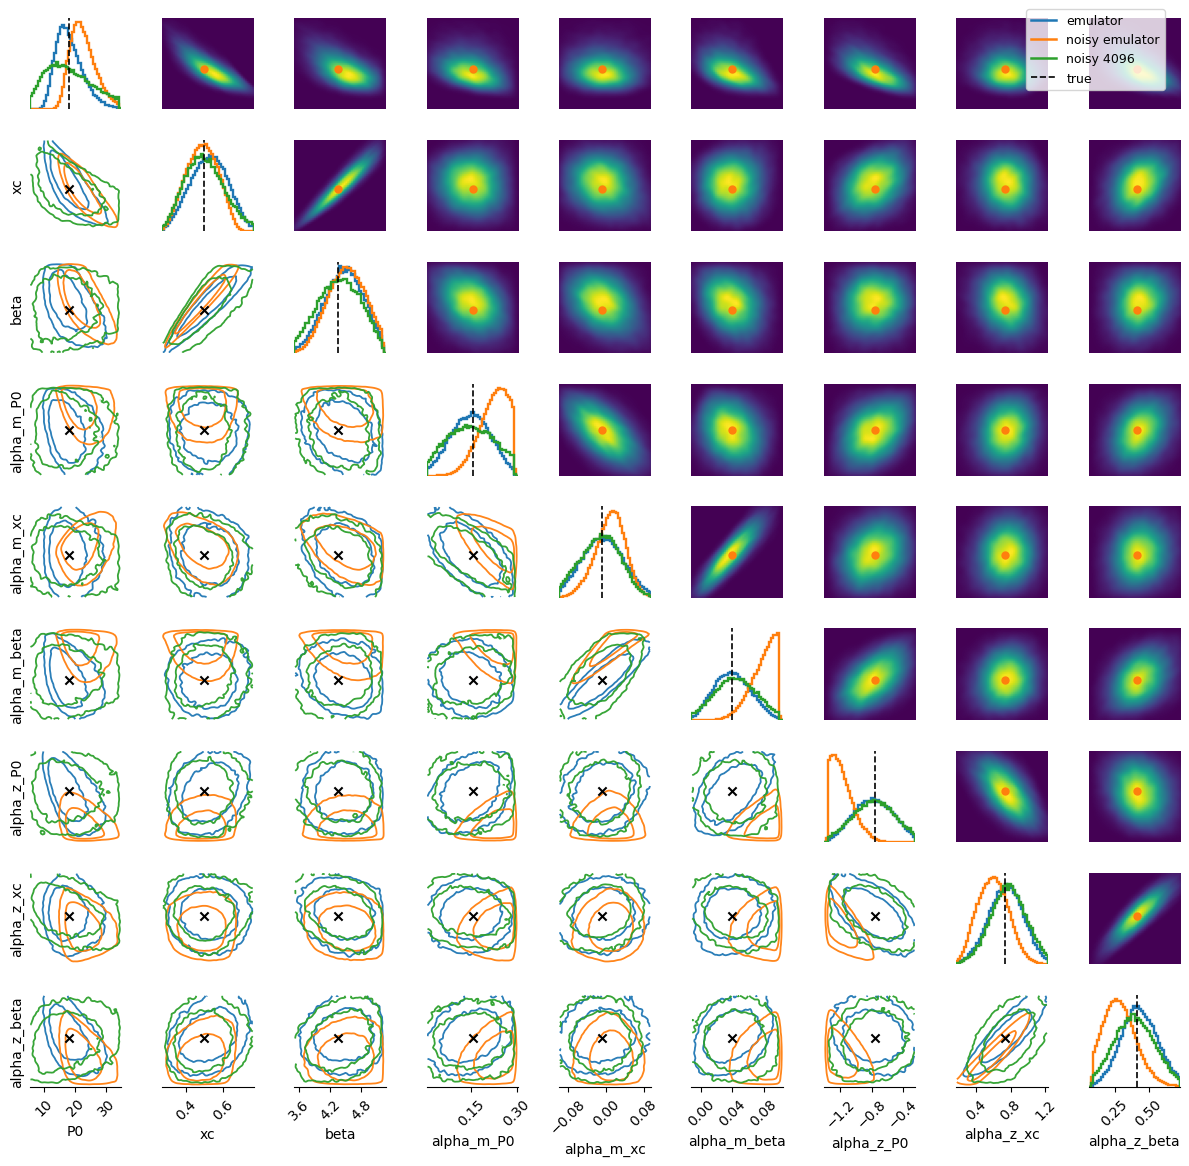

In [114]:
param_names = prepared["param_names"]
n_params = len(param_names)

fig, axes = pairplot(
    torch.as_tensor(samples_clean_np, dtype=torch.float32),
    labels=param_names,
    points=theta_true,
    limits=limits,
    figsize=(12, 12),
    upper="kde",       # only clean samples in upper triangle
    lower="contour",   # will be cleared below
    diag="hist",       # will be cleared below
)

axes = np.asarray(axes)

# Clear diagonal and lower triangle so we control them manually
for i in range(n_params):
    for j in range(n_params):
        if i >= j:
            axes[i, j].clear()

for i in range(n_params):
    ax = axes[i, i]

    for name, data in datasets:
        ax.hist(
            data[:, i],
            bins=45,
            range=limits[i],
            density=True,
            histtype="step",
            linewidth=1.7,
            color=colors[name],
            zorder=5,
        )

    # true value
    ax.axvline(
        true_params[i],
        color="k",
        linestyle="--",
        linewidth=1.2,
        zorder=6,
    )

    ax.set_xlim(limits[i])

for i in range(n_params):
    for j in range(n_params):
        if i > j:
            ax = axes[i, j]

            for name, data in datasets:
                add_contours(
                    ax,
                    data,
                    ix=j,
                    iy=i,
                    limits=limits,
                    color=colors[name],
                    bins=60,
                    smooth=1.0,
                )

            # true point
            ax.scatter(
                true_params[j],
                true_params[i],
                color="k",
                marker="x",
                s=35,
                zorder=10,
            )

            ax.set_xlim(limits[j])
            ax.set_ylim(limits[i])

for i in range(n_params):
    for j in range(n_params):
        ax = axes[i, j]

        ax.tick_params(axis="x", labelrotation=45)
        ax.xaxis.set_major_locator(MaxNLocator(3))
        ax.yaxis.set_major_locator(MaxNLocator(3))

        # only outer labels
        if i == n_params - 1:
            ax.set_xlabel(param_names[j])
        else:
            ax.set_xlabel("")

        if j == 0 and i > 0:
            ax.set_ylabel(param_names[i])
        else:
            ax.set_ylabel("")

# One global legend only
legend_handles = [
    Line2D([0], [0], color=colors["emulator"], lw=1.8, label="emulator"),
    Line2D([0], [0], color=colors["noisy emulator"], lw=1.8, label="noisy emulator"),
    Line2D([0], [0], color=colors["noisy 4096"], lw=1.8, label="noisy 4096"),
    Line2D([0], [0], color="k", lw=1.2, linestyle="--", label="true"),
]

fig.legend(
    handles=legend_handles,
    loc="upper right",
    bbox_to_anchor=(0.98, 0.98),
    frameon=True,
    fontsize=9,
)

plt.tight_layout()
plt.savefig("pairplot_clean_kde_all_hists_all_contours.png", dpi=300)
plt.show()

In [112]:
os.getcwd()

'\\\\wsl.localhost\\myrootfs\\home\\cbllover\\HalfDome\\SBI_analysis'

In [ ]:
fig, axes = pairplot(
    datasets,
    labels=prepared["param_names"],
    points=theta_true,
    limits=limits,
    figsize=(12, 12),
    upper="kde",
    lower="contour",
    diag="hist",
    samples_labels=sample_labels,
)

axes = np.asarray(axes)
n_params = axes.shape[0]

for i in range(n_params):
    for j in range(n_params):
        ax = axes[i, j]

        ax.tick_params(axis="x", labelrotation=45)
        ax.xaxis.set_major_locator(MaxNLocator(3))
        ax.yaxis.set_major_locator(MaxNLocator(3))

plt.tight_layout()
plt.savefig("pairplot_clean_noisy_4096_contours.png", dpi=300)
plt.show()